# Pertemuan 3: Linear Regression dan Polynomial Regression

**Nama:** [Nur Adnan Yusri]

**NIM:** [105841115623]

---

## 📚 Daftar Isi
1. [Setup dan Import Libraries](#setup)
2. [Tugas 1: Simple Linear Regression](#tugas1)
3. [Tugas 2: Multiple Linear Regression - California Housing](#tugas2)
4. [Tugas 3: Polynomial Regression](#tugas3)
5. [Tugas 4: Real-World Application - Prediksi Gaji](#tugas4)
6. [Kesimpulan](#kesimpulan)

<a id='setup'></a>
## 1. Setup dan Import Libraries

Mengimport semua library yang diperlukan untuk praktikum.

In [125]:
# Import library utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

# Setting visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(" Semua library berhasil diimport!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

 Semua library berhasil diimport!
NumPy version: 2.3.5
Pandas version: 2.3.3


---
<a id='tugas1'></a>
## 2. Tugas 1: Simple Linear Regression (20 poin)

### Objektif:
1. Membuat dataset sendiri
2. Membuat scatter plot data
3. Implementasi Simple Linear Regression
4. Visualisasi regression line
5. Menghitung dan interpretasi R², MAE, dan RMSE
6. Membuat prediksi untuk 5 nilai baru

### 1.1 Generate Dataset

Membuat dataset sintesis yang merepresentasikan hubungan linear antara jam belajar dan nilai ujian.

In [126]:
# Set random seed untuk reproducibility
np.random.seed(42)

# Generate data: Hubungan antara jam belajar (X) dan nilai ujian (y)
X_simple = np.random.rand(100, 1) * 10  
y_simple = 10 * X_simple.squeeze() + 50 + np.random.randn(100) * 5  

# Membuat DataFrame untuk kemudahan
df_simple = pd.DataFrame({
    'Jam_Belajar': X_simple.squeeze(),
    'Nilai_Ujian': y_simple
})

print(" Dataset Simple Linear Regression")
print("="*50)
print(f"Jumlah data: {len(df_simple)}")
print(f"\nStatistik Deskriptif:")
print(df_simple.describe())
print(f"\n5 data pertama:")
print(df_simple.head())

 Dataset Simple Linear Regression
Jumlah data: 100

Statistik Deskriptif:
       Jam_Belajar  Nilai_Ujian
count   100.000000   100.000000
mean      4.701807    97.012673
std       2.974894    29.413357
min       0.055221    49.925608
25%       1.932008    71.926021
50%       4.641425    94.728704
75%       7.302031   123.675376
max       9.868869   152.597808

5 data pertama:
   Jam_Belajar  Nilai_Ujian
0     3.745401    87.889247
1     9.507143   143.576394
2     7.319939   123.658198
3     5.986585    99.928004
4     1.560186    64.503505


### 1.2 Visualisasi Data (Scatter Plot)

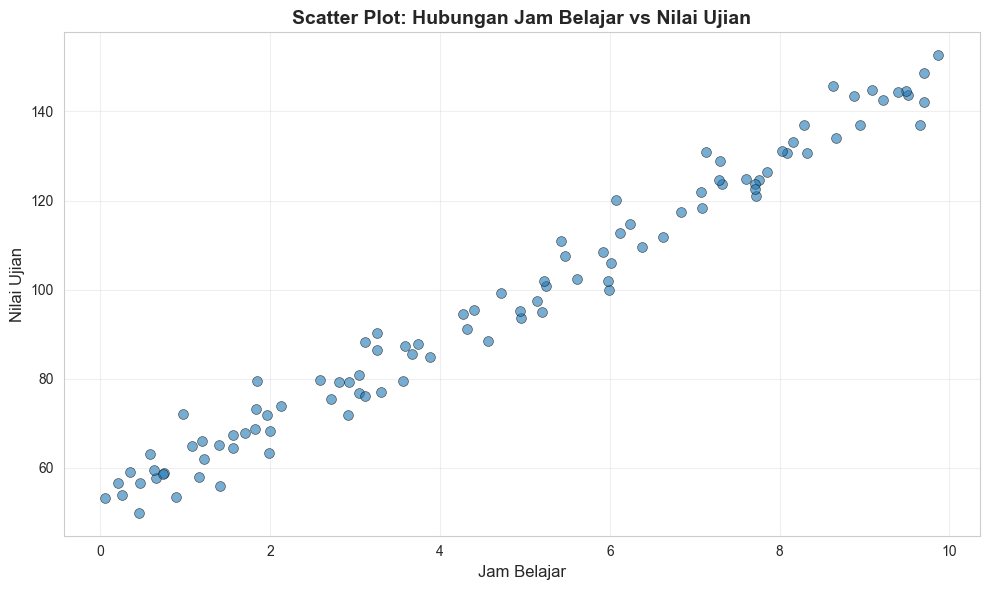


📊 Interpretasi Scatter Plot:
Terlihat ada pola linear positif antara jam belajar dan nilai ujian.
Semakin banyak jam belajar, cenderung semakin tinggi nilai ujian yang diperoleh.


In [127]:
plt.figure(figsize=(10, 6))
plt.scatter(df_simple['Jam_Belajar'], df_simple['Nilai_Ujian'], 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel('Jam Belajar', fontsize=12)
plt.ylabel('Nilai Ujian', fontsize=12)
plt.title('Scatter Plot: Hubungan Jam Belajar vs Nilai Ujian', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Interpretasi Scatter Plot:")
print("Terlihat ada pola linear positif antara jam belajar dan nilai ujian.")
print("Semakin banyak jam belajar, cenderung semakin tinggi nilai ujian yang diperoleh.")

### 1.3 Split Data dan Training Model

In [128]:
# Split data 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

print(f" Data Split:")
print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# Train model
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Prediksi
y_pred_train = model_simple.predict(X_train)
y_pred_test = model_simple.predict(X_test)

print("\n Model berhasil dilatih!")
print("\n Parameter Model:")
print(f"Intercept (β₀): {model_simple.intercept_:.4f}")
print(f"Coefficient (β₁): {model_simple.coef_[0]:.4f}")
print(f"\n Persamaan Regresi:")
print(f"Nilai Ujian = {model_simple.intercept_:.2f} + {model_simple.coef_[0]:.2f} × Jam Belajar")

 Data Split:
Training set: 80 samples
Testing set: 20 samples

 Model berhasil dilatih!

 Parameter Model:
Intercept (β₀): 50.7146
Coefficient (β₁): 9.7993

 Persamaan Regresi:
Nilai Ujian = 50.71 + 9.80 × Jam Belajar


### 1.4 Visualisasi Regression Line

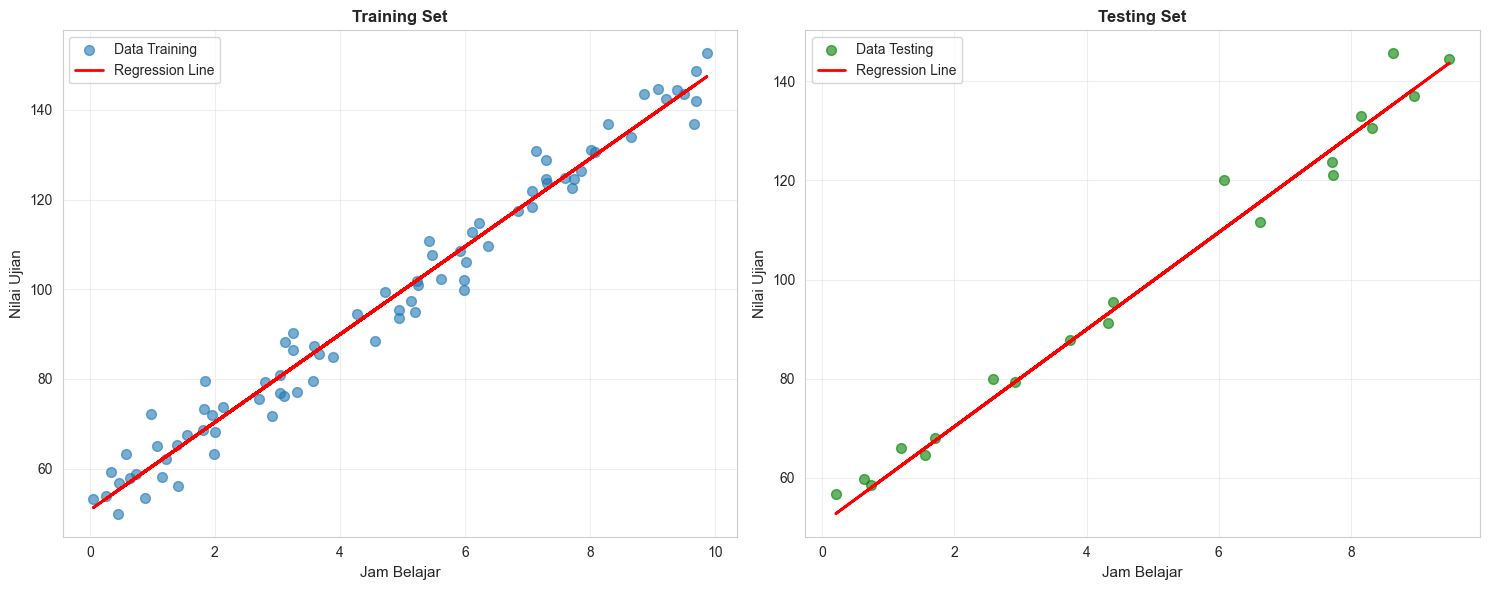

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Training Set
axes[0].scatter(X_train, y_train, alpha=0.6, s=50, label='Data Training')
axes[0].plot(X_train, y_pred_train, color='red', linewidth=2, label='Regression Line')
axes[0].set_xlabel('Jam Belajar', fontsize=11)
axes[0].set_ylabel('Nilai Ujian', fontsize=11)
axes[0].set_title('Training Set', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Testing Set
axes[1].scatter(X_test, y_test, alpha=0.6, s=50, color='green', label='Data Testing')
axes[1].plot(X_test, y_pred_test, color='red', linewidth=2, label='Regression Line')
axes[1].set_xlabel('Jam Belajar', fontsize=11)
axes[1].set_ylabel('Nilai Ujian', fontsize=11)
axes[1].set_title('Testing Set', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.5 Evaluasi Model (R², MAE, RMSE)

In [130]:
# Hitung metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("="*60)
print(" EVALUASI MODEL - SIMPLE LINEAR REGRESSION")
print("="*60)
print(f"\n{'Metric':<20} {'Training':<15} {'Testing':<15}")
print("-"*60)
print(f"{'R² Score':<20} {train_r2:<15.4f} {test_r2:<15.4f}")
print(f"{'MAE':<20} {train_mae:<15.4f} {test_mae:<15.4f}")
print(f"{'RMSE':<20} {train_rmse:<15.4f} {test_rmse:<15.4f}")
print("="*60)

print("\n INTERPRETASI HASIL:")
print("-"*60)
print(f"1. R² Score Test = {test_r2:.4f}")
if test_r2 > 0.9:
    print("   → Model SANGAT BAIK! Menjelaskan >90% variasi data")
elif test_r2 > 0.7:
    print("   → Model BAIK! Menjelaskan >70% variasi data")
elif test_r2 > 0.5:
    print("   → Model CUKUP! Menjelaskan >50% variasi data")
else:
    print("   → Model KURANG BAIK! Menjelaskan <50% variasi data")

print(f"\n2. MAE Test = {test_mae:.4f}")
print(f"   → Rata-rata kesalahan prediksi adalah {test_mae:.2f} poin")

print(f"\n3. RMSE Test = {test_rmse:.4f}")
print(f"   → Root Mean Square Error adalah {test_rmse:.2f} poin")
print("   → RMSE memberi penalti lebih besar pada error yang besar")

print(f"\n4. Selisih Train vs Test R²: {abs(train_r2 - test_r2):.4f}")
if abs(train_r2 - test_r2) < 0.05:
    print("   → Model TIDAK OVERFIT (selisih kecil)")
else:
    print("   → Perlu diwaspadai, ada indikasi overfitting")

 EVALUASI MODEL - SIMPLE LINEAR REGRESSION

Metric               Training        Testing        
------------------------------------------------------------
R² Score             0.9746          0.9825         
MAE                  3.6736          2.9567         
RMSE                 4.6035          4.0426         

 INTERPRETASI HASIL:
------------------------------------------------------------
1. R² Score Test = 0.9825
   → Model SANGAT BAIK! Menjelaskan >90% variasi data

2. MAE Test = 2.9567
   → Rata-rata kesalahan prediksi adalah 2.96 poin

3. RMSE Test = 4.0426
   → Root Mean Square Error adalah 4.04 poin
   → RMSE memberi penalti lebih besar pada error yang besar

4. Selisih Train vs Test R²: 0.0079
   → Model TIDAK OVERFIT (selisih kecil)


### 1.6 Prediksi untuk 5 Nilai Baru


 PREDIKSI NILAI UJIAN UNTUK DATA BARU
 Jam Belajar  Prediksi Nilai
         2.5       75.212876
         4.0       89.911861
         6.0      109.510509
         8.5      134.008818
         9.5      143.808141


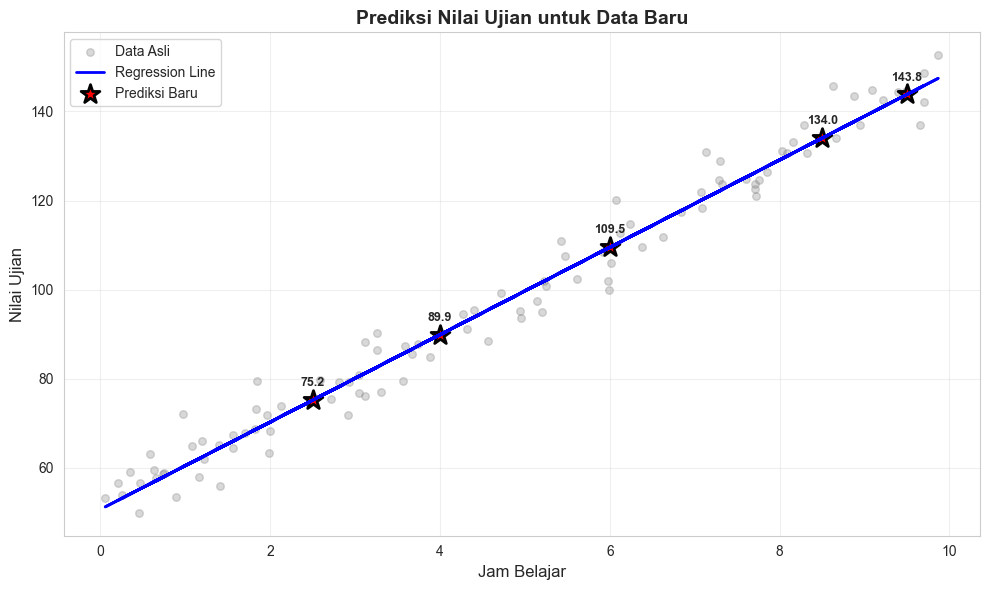


💡 Interpretasi Prediksi:
Jika mahasiswa belajar 2.5 jam → Prediksi nilai: 75.21
Jika mahasiswa belajar 9.5 jam → Prediksi nilai: 143.81

Setiap penambahan 1 jam belajar meningkatkan nilai sekitar 9.80 poin


In [131]:
# Membuat 5 nilai baru untuk prediksi
nilai_baru = np.array([[2.5], [4.0], [6.0], [8.5], [9.5]])

prediksi_baru = model_simple.predict(nilai_baru)

# Membuat DataFrame hasil
hasil_prediksi = pd.DataFrame({
    'Jam Belajar': nilai_baru.squeeze(),
    'Prediksi Nilai': prediksi_baru
})

print("\n" + "="*50)
print(" PREDIKSI NILAI UJIAN UNTUK DATA BARU")
print("="*50)
print(hasil_prediksi.to_string(index=False))
print("="*50)

# Visualisasi prediksi
plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y_simple, alpha=0.3, s=30, label='Data Asli', color='gray')
plt.plot(X_simple, model_simple.predict(X_simple), color='blue', 
         linewidth=2, label='Regression Line')
plt.scatter(nilai_baru, prediksi_baru, color='red', s=200, 
           marker='*', label='Prediksi Baru', edgecolors='black', linewidth=2)

# Annotate prediksi
for i, (x, y) in enumerate(zip(nilai_baru.squeeze(), prediksi_baru)):
    plt.annotate(f'{y:.1f}', (x, y), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.xlabel('Jam Belajar', fontsize=12)
plt.ylabel('Nilai Ujian', fontsize=12)
plt.title('Prediksi Nilai Ujian untuk Data Baru', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Interpretasi Prediksi:")
print(f"Jika mahasiswa belajar {nilai_baru[0][0]} jam → Prediksi nilai: {prediksi_baru[0]:.2f}")
print(f"Jika mahasiswa belajar {nilai_baru[4][0]} jam → Prediksi nilai: {prediksi_baru[4]:.2f}")
print(f"\nSetiap penambahan 1 jam belajar meningkatkan nilai sekitar {model_simple.coef_[0]:.2f} poin")

---
<a id='tugas2'></a>
## 3. Tugas 2: Multiple Linear Regression - California Housing (35 poin)

### Objektif:
1. Load dan eksplorasi dataset California Housing
2. Feature selection berdasarkan correlation
3. Split data (80-20)
4. Train model dengan semua fitur
5. Train model dengan top 5 fitur
6. Bandingkan performa kedua model
7. Analisis residuals
8. Interpretasi koefisien model

### 2.1 Load Dataset dan Exploratory Data Analysis

In [132]:
# Load California Housing dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing['Price'] = housing.target

print("="*70)
print(" CALIFORNIA HOUSING DATASET")
print("="*70)
print(f"\n Shape: {df_housing.shape}")
print(f"Jumlah data: {len(df_housing):,}")
print(f"Jumlah fitur: {len(housing.feature_names)}")
print(f"\n Deskripsi Dataset:")
print(housing.DESCR[:500] + "...")

print("\n" + "="*70)
print(" INFO DATASET")
print("="*70)
print(df_housing.info())

print("\n" + "="*70)
print(" 5 DATA PERTAMA")
print("="*70)
print(df_housing.head())

print("\n" + "="*70)
print(" STATISTIK DESKRIPTIF")
print("="*70)
print(df_housing.describe())

 CALIFORNIA HOUSING DATASET

 Shape: (20640, 9)
Jumlah data: 20,640
Jumlah fitur: 8

 Deskripsi Dataset:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group popu...

 INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640

In [133]:
# Check missing values
print("\n🔍 Checking Missing Values:")
print(df_housing.isnull().sum())
print("\n✅ Tidak ada missing values!")


🔍 Checking Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

✅ Tidak ada missing values!


### 2.2 Visualisasi Distribusi Data

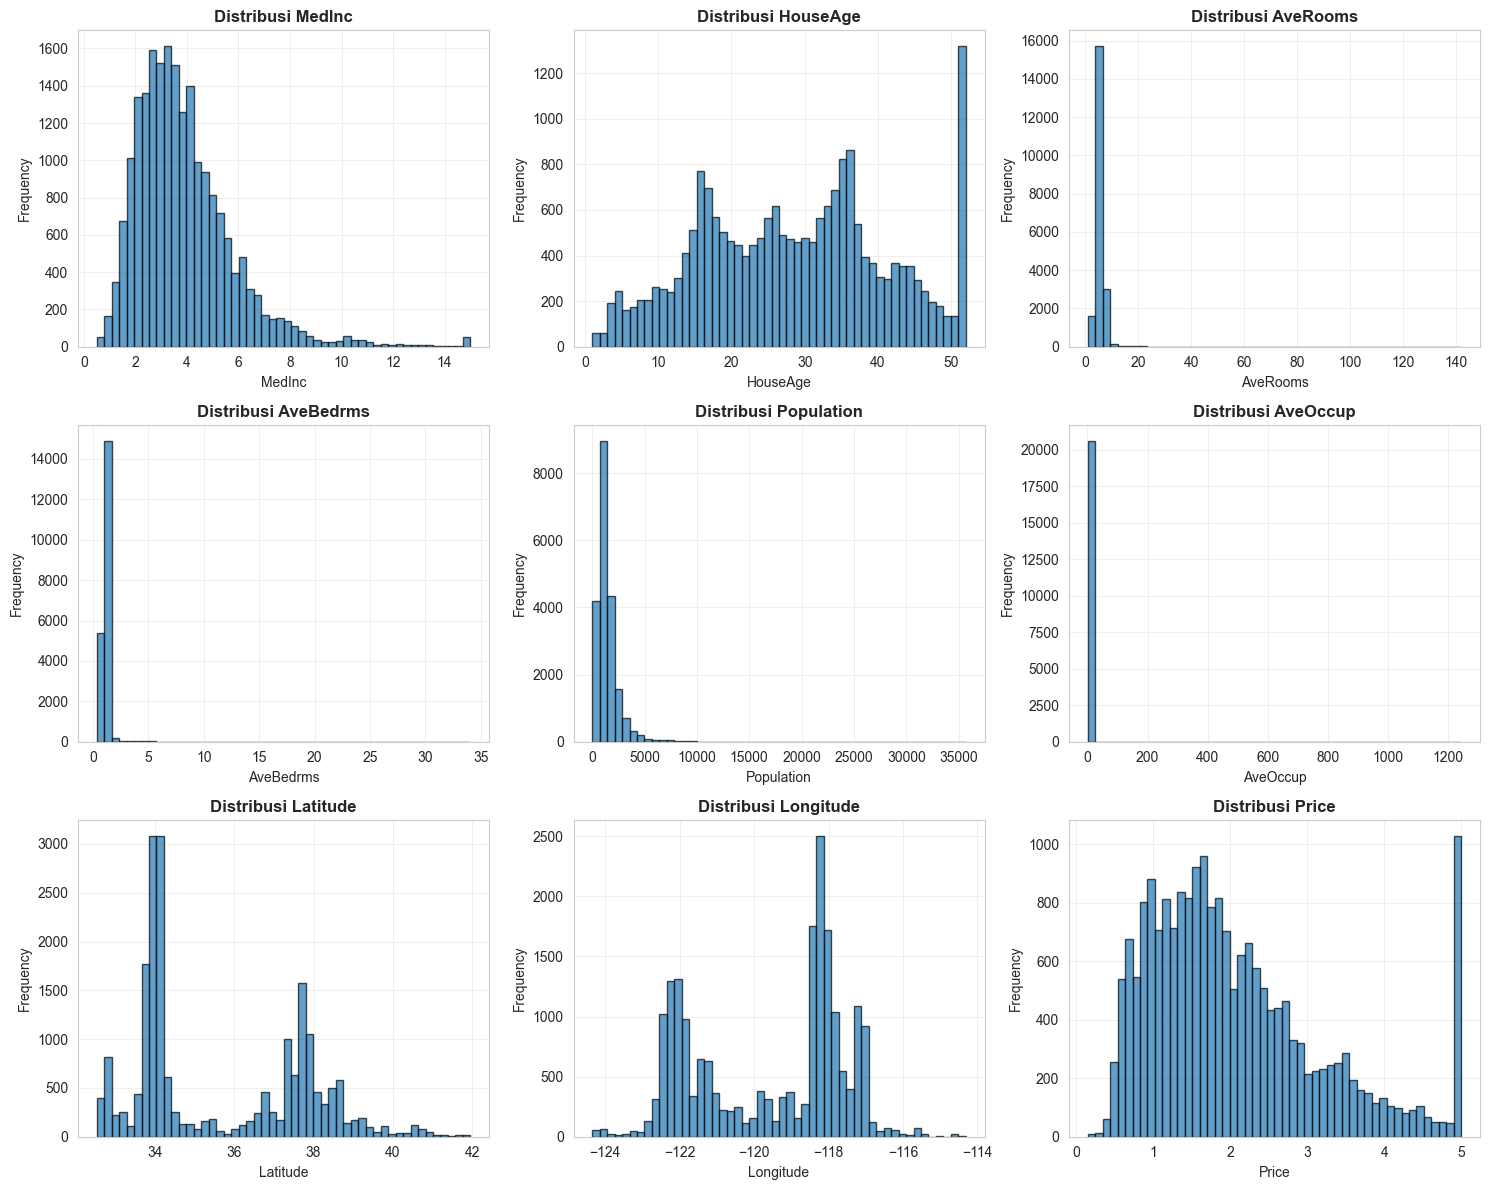

In [134]:
# Histogram untuk semua fitur
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df_housing.columns):
    axes[idx].hist(df_housing[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribusi {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3 Correlation Analysis dan Feature Selection

 KORELASI DENGAN PRICE (TARGET)
Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64


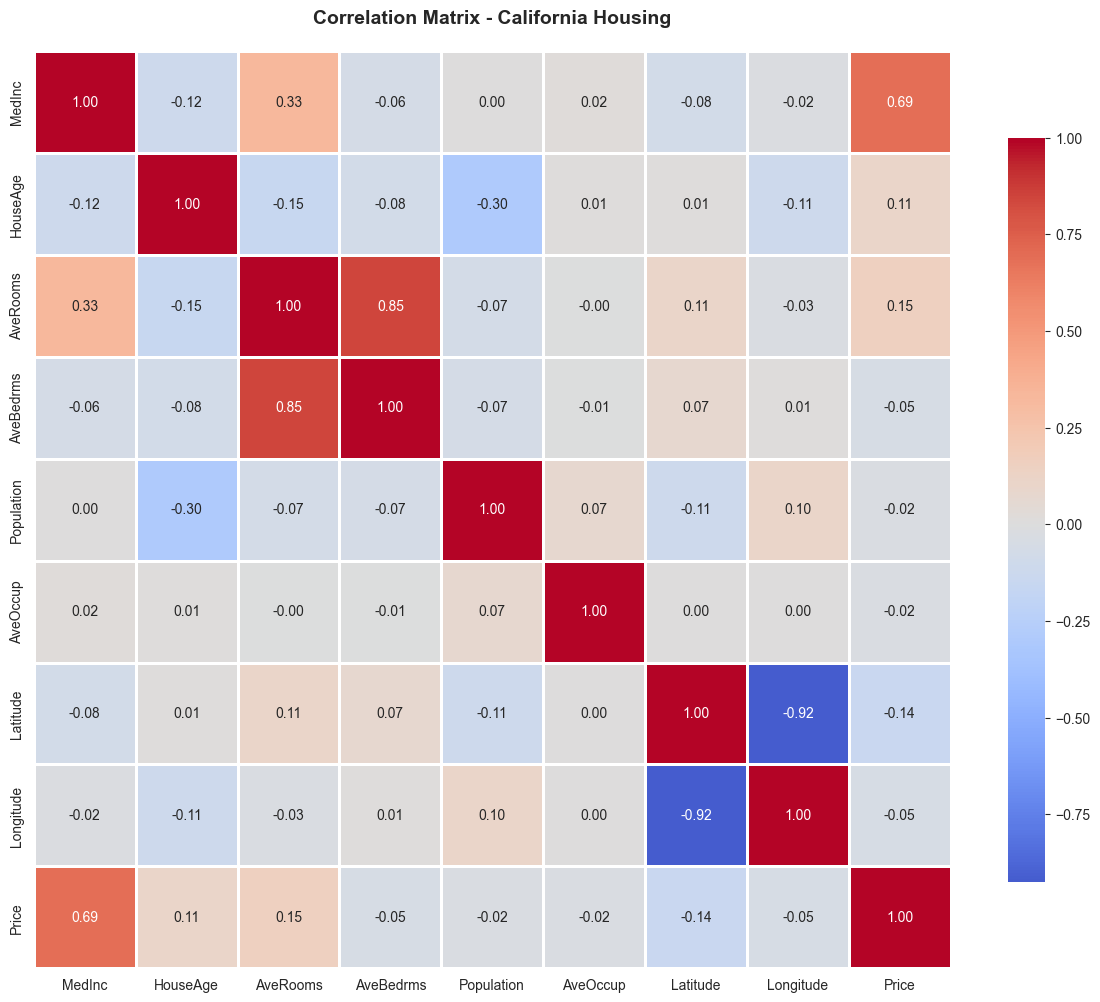

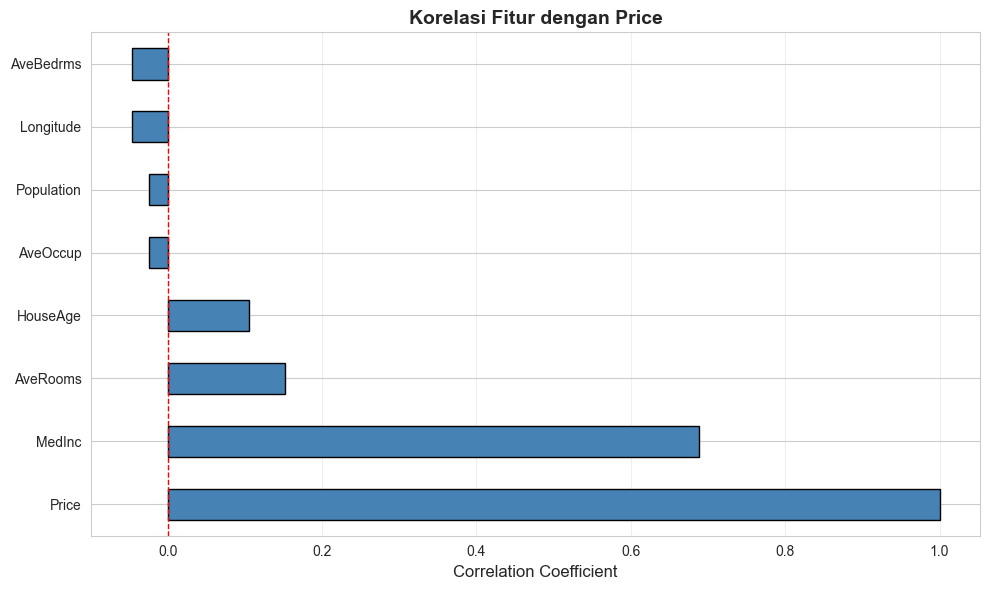


 TOP 5 FITUR BERDASARKAN KORELASI
1. MedInc          → Korelasi: 0.6881
2. AveRooms        → Korelasi: 0.1519
3. HouseAge        → Korelasi: 0.1056
4. AveOccup        → Korelasi: -0.0237
5. Population      → Korelasi: -0.0246


In [135]:
# Hitung korelasi
correlation_matrix = df_housing.corr()

# Korelasi dengan Price
correlations_with_price = correlation_matrix['Price'].sort_values(ascending=False)

print("="*50)
print(" KORELASI DENGAN PRICE (TARGET)")
print("="*50)
print(correlations_with_price)

# Visualisasi correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
           fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - California Housing', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Bar plot korelasi dengan Price
plt.figure(figsize=(10, 6))
correlations_with_price[:-1].plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Korelasi Fitur dengan Price', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Top 5 fitur berdasarkan korelasi absolut
top5_features = correlations_with_price[1:6].index.tolist()  # Exclude Price itself
print("\n" + "="*50)
print(" TOP 5 FITUR BERDASARKAN KORELASI")
print("="*50)
for i, feat in enumerate(top5_features, 1):
    print(f"{i}. {feat:<15} → Korelasi: {correlations_with_price[feat]:.4f}")

### 2.4 Split Data

In [136]:
# Prepare data
X_all = df_housing.drop('Price', axis=1)
y = df_housing['Price']

X_top5 = df_housing[top5_features]

# Split data 80-20
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

X_top5_train, X_top5_test, y_top5_train, y_top5_test = train_test_split(
    X_top5, y, test_size=0.2, random_state=42
)

print("="*60)
print("✂️ DATA SPLIT (80% Train - 20% Test)")
print("="*60)
print(f"\nModel dengan SEMUA fitur:")
print(f"  Training: {X_all_train.shape}")
print(f"  Testing:  {X_all_test.shape}")
print(f"\nModel dengan TOP 5 fitur:")
print(f"  Training: {X_top5_train.shape}")
print(f"  Testing:  {X_top5_test.shape}")

✂️ DATA SPLIT (80% Train - 20% Test)

Model dengan SEMUA fitur:
  Training: (16512, 8)
  Testing:  (4128, 8)

Model dengan TOP 5 fitur:
  Training: (16512, 5)
  Testing:  (4128, 5)


### 2.5 Train Model dengan SEMUA Fitur

 Model dengan semua fitur berhasil dilatih!

 KOEFISIEN MODEL (SEMUA FITUR)
   Feature  Coefficient
 AveBedrms     0.783145
    MedInc     0.448675
  HouseAge     0.009724
Population    -0.000002
  AveOccup    -0.003526
  AveRooms    -0.123323
  Latitude    -0.419792
 Longitude    -0.433708

Intercept: -37.0233


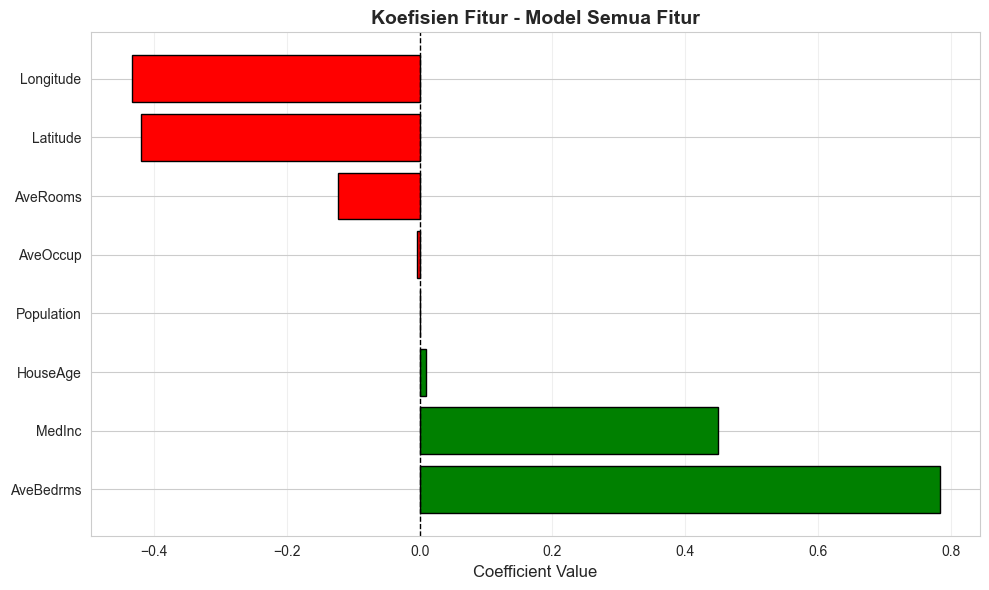

In [137]:
# Train model dengan semua fitur
model_all = LinearRegression()
model_all.fit(X_all_train, y_all_train)

# Prediksi
y_all_pred_train = model_all.predict(X_all_train)
y_all_pred_test = model_all.predict(X_all_test)

print(" Model dengan semua fitur berhasil dilatih!")
print("\n" + "="*60)
print(" KOEFISIEN MODEL (SEMUA FITUR)")
print("="*60)

coef_all = pd.DataFrame({
    'Feature': X_all.columns,
    'Coefficient': model_all.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_all.to_string(index=False))
print(f"\nIntercept: {model_all.intercept_:.4f}")

# Visualisasi koefisien
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in coef_all['Coefficient']]
plt.barh(coef_all['Feature'], coef_all['Coefficient'], color=colors, edgecolor='black')
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Koefisien Fitur - Model Semua Fitur', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 2.6 Train Model dengan TOP 5 Fitur

 Model dengan top 5 fitur berhasil dilatih!

 KOEFISIEN MODEL (TOP 5 FITUR)
   Feature  Coefficient
    MedInc     0.445359
  HouseAge     0.017658
Population     0.000027
  AveOccup    -0.004345
  AveRooms    -0.026778

Intercept: -0.0407


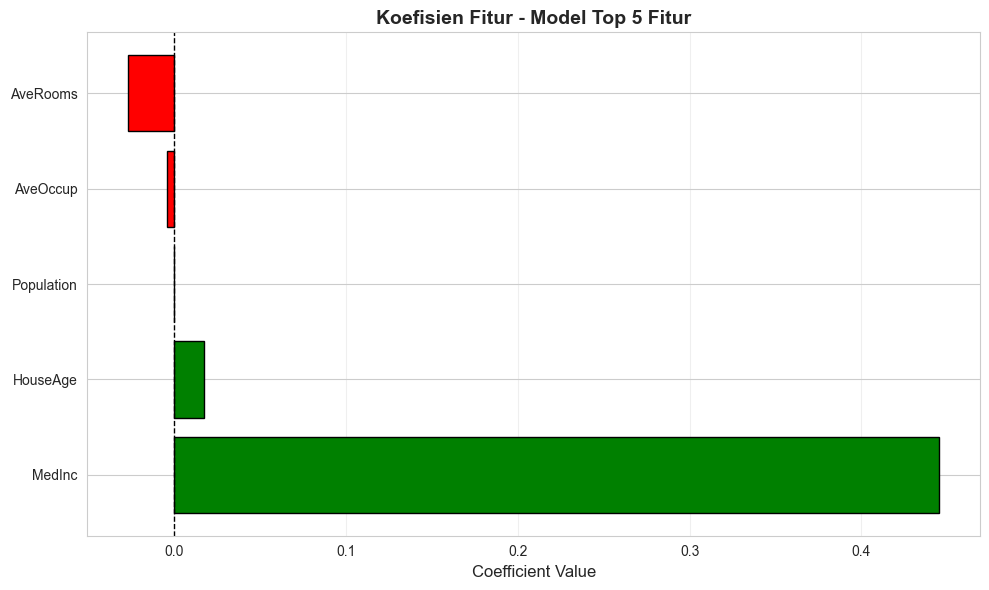

In [138]:
# Train model dengan top 5 fitur
model_top5 = LinearRegression()
model_top5.fit(X_top5_train, y_top5_train)

# Prediksi
y_top5_pred_train = model_top5.predict(X_top5_train)
y_top5_pred_test = model_top5.predict(X_top5_test)

print(" Model dengan top 5 fitur berhasil dilatih!")
print("\n" + "="*60)
print(" KOEFISIEN MODEL (TOP 5 FITUR)")
print("="*60)

coef_top5 = pd.DataFrame({
    'Feature': X_top5.columns,
    'Coefficient': model_top5.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_top5.to_string(index=False))
print(f"\nIntercept: {model_top5.intercept_:.4f}")

# Visualisasi koefisien
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in coef_top5['Coefficient']]
plt.barh(coef_top5['Feature'], coef_top5['Coefficient'], color=colors, edgecolor='black')
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Koefisien Fitur - Model Top 5 Fitur', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 2.7 Perbandingan Performa Kedua Model

 PERBANDINGAN PERFORMA MODEL
         Model Dataset  R² Score      MAE     RMSE
  All Features   Train  0.612551 0.528628 0.719676
  All Features    Test  0.575788 0.533200 0.745581
Top 5 Features   Train  0.518063 0.597042 0.802647
Top 5 Features    Test  0.499288 0.601570 0.810023


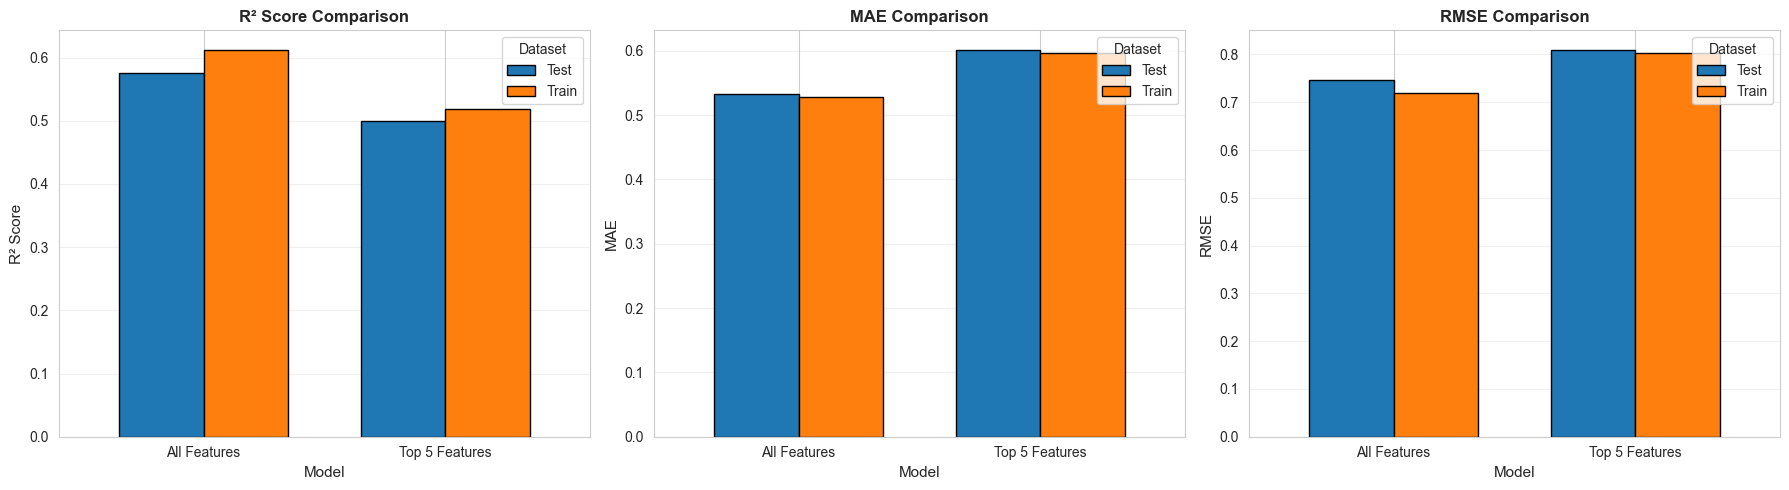


 INTERPRETASI PERBANDINGAN:

1. Model SEMUA Fitur:
   - R² Test: 0.5758
   - MAE Test: 0.5332 (error ±$53k)
   - RMSE Test: 0.7456

2. Model TOP 5 Fitur:
   - R² Test: 0.4993
   - MAE Test: 0.6016 (error ±$60k)
   - RMSE Test: 0.8100

3. Perbedaan Performa:
   - Selisih R²: 0.0765
   - Selisih MAE: 0.0684

 KESIMPULAN: Model dengan SEMUA fitur memberikan performa LEBIH BAIK


In [139]:
# Evaluasi Model ALL Features
all_train_r2 = r2_score(y_all_train, y_all_pred_train)
all_test_r2 = r2_score(y_all_test, y_all_pred_test)
all_train_mae = mean_absolute_error(y_all_train, y_all_pred_train)
all_test_mae = mean_absolute_error(y_all_test, y_all_pred_test)
all_train_rmse = np.sqrt(mean_squared_error(y_all_train, y_all_pred_train))
all_test_rmse = np.sqrt(mean_squared_error(y_all_test, y_all_pred_test))

# Evaluasi Model TOP 5 Features
top5_train_r2 = r2_score(y_top5_train, y_top5_pred_train)
top5_test_r2 = r2_score(y_top5_test, y_top5_pred_test)
top5_train_mae = mean_absolute_error(y_top5_train, y_top5_pred_train)
top5_test_mae = mean_absolute_error(y_top5_test, y_top5_pred_test)
top5_train_rmse = np.sqrt(mean_squared_error(y_top5_train, y_top5_pred_train))
top5_test_rmse = np.sqrt(mean_squared_error(y_top5_test, y_top5_pred_test))

# Buat comparison table
comparison = pd.DataFrame({
    'Model': ['All Features', 'All Features', 'Top 5 Features', 'Top 5 Features'],
    'Dataset': ['Train', 'Test', 'Train', 'Test'],
    'R² Score': [all_train_r2, all_test_r2, top5_train_r2, top5_test_r2],
    'MAE': [all_train_mae, all_test_mae, top5_train_mae, top5_test_mae],
    'RMSE': [all_train_rmse, all_test_rmse, top5_train_rmse, top5_test_rmse]
})

print("="*80)
print(" PERBANDINGAN PERFORMA MODEL")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['R² Score', 'MAE', 'RMSE']
for idx, metric in enumerate(metrics):
    data_to_plot = comparison.pivot(index='Model', columns='Dataset', values=metric)
    data_to_plot.plot(kind='bar', ax=axes[idx], edgecolor='black', width=0.7)
    axes[idx].set_title(f'{metric} Comparison', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel(metric, fontsize=11)
    axes[idx].set_xlabel('Model', fontsize=11)
    axes[idx].legend(title='Dataset')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n INTERPRETASI PERBANDINGAN:")
print("="*80)
print(f"\n1. Model SEMUA Fitur:")
print(f"   - R² Test: {all_test_r2:.4f}")
print(f"   - MAE Test: {all_test_mae:.4f} (error ±${all_test_mae*100:.0f}k)")
print(f"   - RMSE Test: {all_test_rmse:.4f}")

print(f"\n2. Model TOP 5 Fitur:")
print(f"   - R² Test: {top5_test_r2:.4f}")
print(f"   - MAE Test: {top5_test_mae:.4f} (error ±${top5_test_mae*100:.0f}k)")
print(f"   - RMSE Test: {top5_test_rmse:.4f}")

print(f"\n3. Perbedaan Performa:")
r2_diff = abs(all_test_r2 - top5_test_r2)
mae_diff = abs(all_test_mae - top5_test_mae)
print(f"   - Selisih R²: {r2_diff:.4f}")
print(f"   - Selisih MAE: {mae_diff:.4f}")

if r2_diff < 0.02:
    print("\n KESIMPULAN: Model dengan Top 5 fitur memberikan performa yang HAMPIR SAMA")
    print("   dengan model semua fitur, tapi lebih SEDERHANA dan EFISIEN!")
elif all_test_r2 > top5_test_r2:
    print("\n KESIMPULAN: Model dengan SEMUA fitur memberikan performa LEBIH BAIK")
else:
    print("\n KESIMPULAN: Model dengan TOP 5 fitur memberikan performa LEBIH BAIK")

### 2.8 Visualisasi Predicted vs Actual

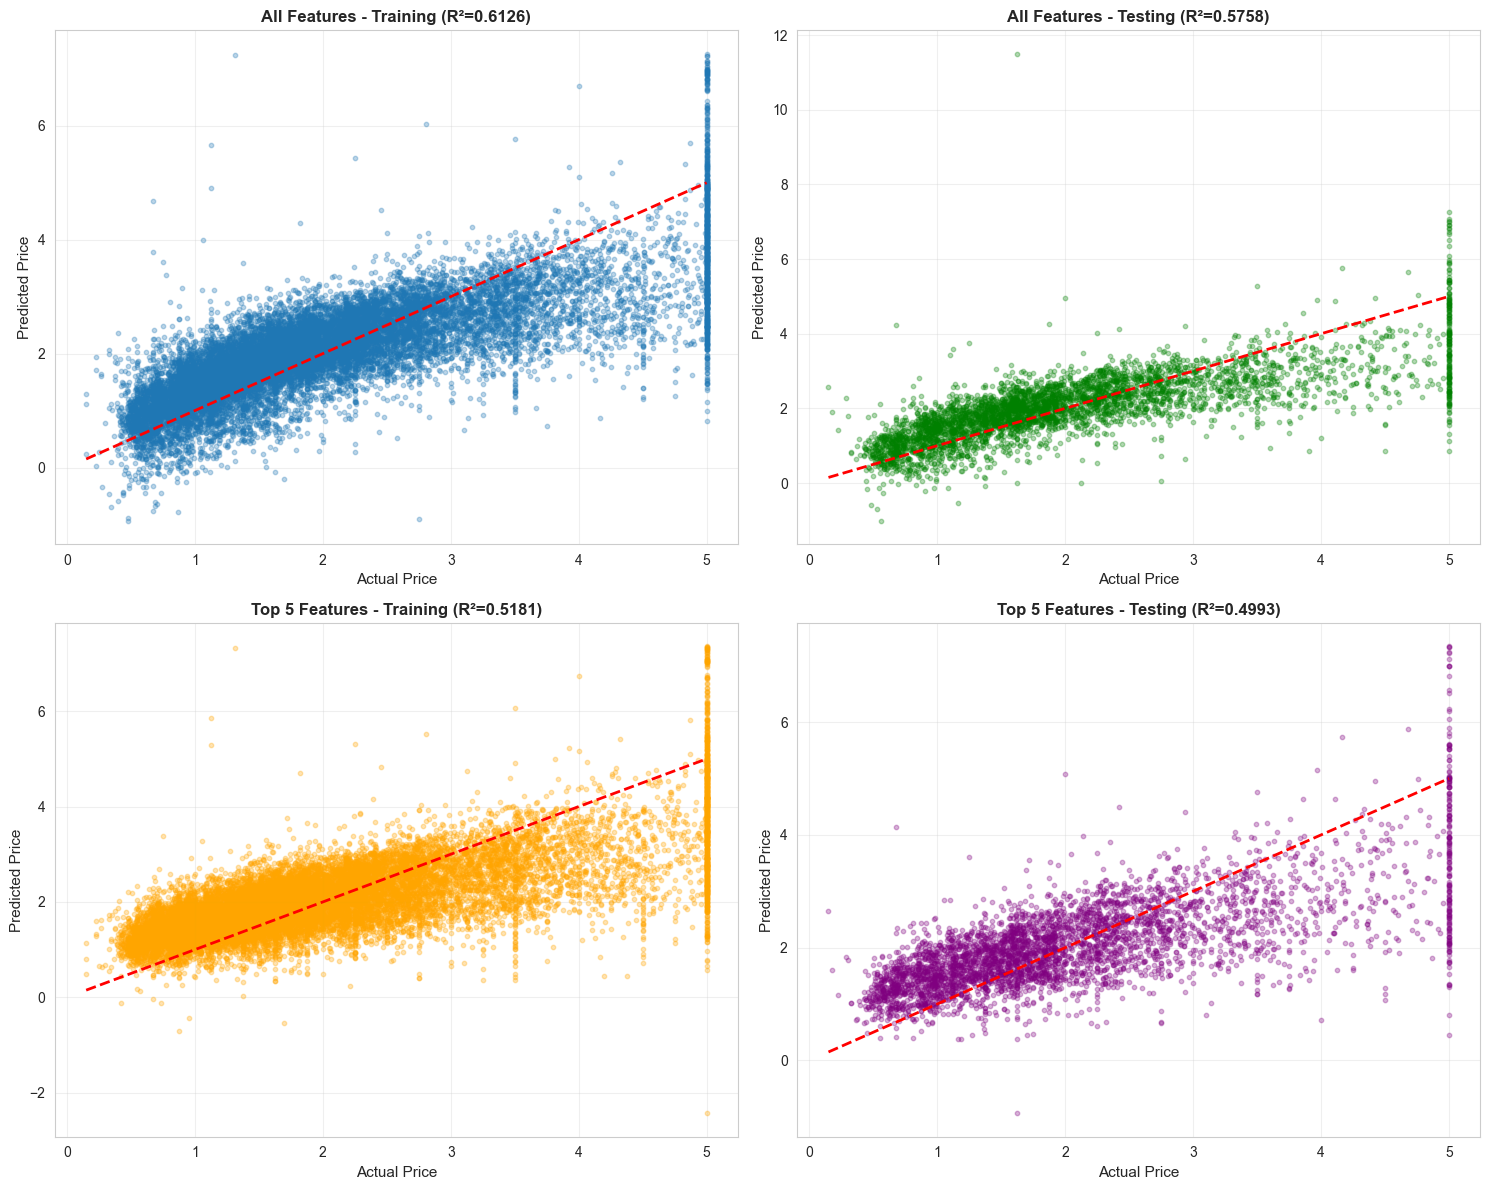

💡 Interpretasi Plot Predicted vs Actual:
- Titik yang dekat dengan garis merah menunjukkan prediksi yang akurat
- Penyebaran yang acak di sekitar garis adalah indikasi model yang baik
- Pola tertentu (misalnya kurva) mengindikasikan model mungkin perlu perbaikan


In [140]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Model All Features - Train
axes[0, 0].scatter(y_all_train, y_all_pred_train, alpha=0.3, s=10)
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price', fontsize=11)
axes[0, 0].set_ylabel('Predicted Price', fontsize=11)
axes[0, 0].set_title(f'All Features - Training (R²={all_train_r2:.4f})', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Model All Features - Test
axes[0, 1].scatter(y_all_test, y_all_pred_test, alpha=0.3, s=10, color='green')
axes[0, 1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Price', fontsize=11)
axes[0, 1].set_ylabel('Predicted Price', fontsize=11)
axes[0, 1].set_title(f'All Features - Testing (R²={all_test_r2:.4f})', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Model Top 5 - Train
axes[1, 0].scatter(y_top5_train, y_top5_pred_train, alpha=0.3, s=10, color='orange')
axes[1, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Price', fontsize=11)
axes[1, 0].set_ylabel('Predicted Price', fontsize=11)
axes[1, 0].set_title(f'Top 5 Features - Training (R²={top5_train_r2:.4f})', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Model Top 5 - Test
axes[1, 1].scatter(y_top5_test, y_top5_pred_test, alpha=0.3, s=10, color='purple')
axes[1, 1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Price', fontsize=11)
axes[1, 1].set_ylabel('Predicted Price', fontsize=11)
axes[1, 1].set_title(f'Top 5 Features - Testing (R²={top5_test_r2:.4f})', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Interpretasi Plot Predicted vs Actual:")
print("- Titik yang dekat dengan garis merah menunjukkan prediksi yang akurat")
print("- Penyebaran yang acak di sekitar garis adalah indikasi model yang baik")
print("- Pola tertentu (misalnya kurva) mengindikasikan model mungkin perlu perbaikan")

### 2.9 Residual Analysis

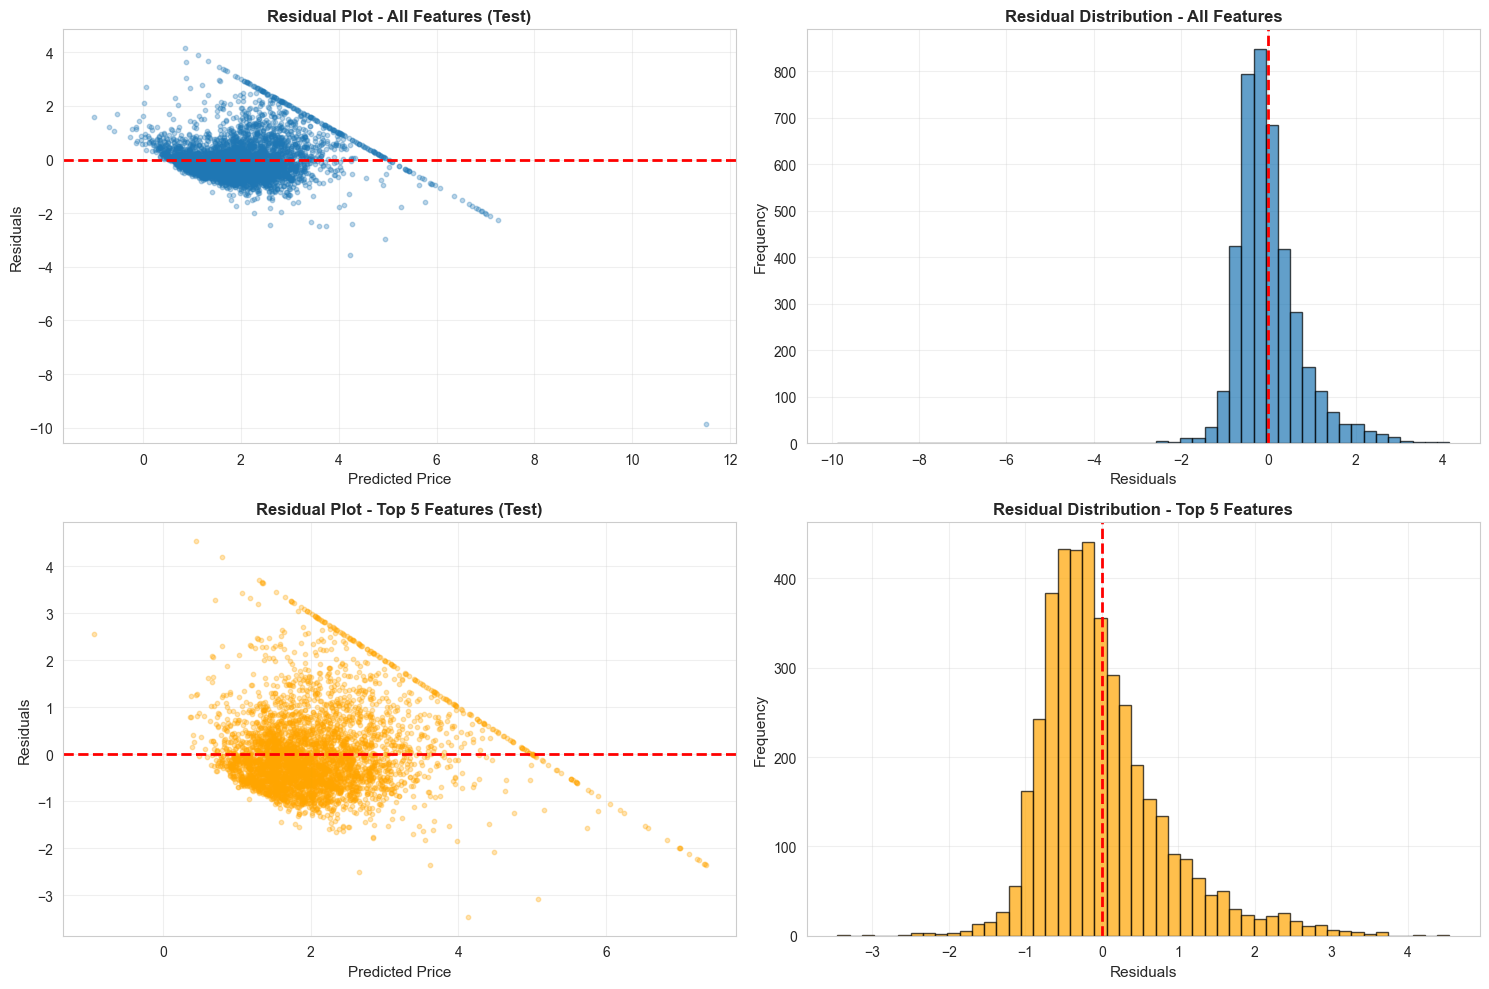


 STATISTIK RESIDUAL

Model ALL Features:
  Mean Residual: 0.003479
  Std Residual: 0.7457
  Min Residual: -9.8753
  Max Residual: 4.1484

Model TOP 5 Features:
  Mean Residual: 0.001479
  Std Residual: 0.8101
  Min Residual: -3.4594
  Max Residual: 4.5453

 INTERPRETASI RESIDUAL ANALYSIS:
 INDIKATOR MODEL BAIK:
   1. Residual tersebar acak di sekitar 0 (tidak ada pola)
   2. Distribusi residual mendekati normal (bell-shaped)
   3. Mean residual mendekati 0
   4. Variance konstan (homoscedasticity)

 Mean residual sangat dekat dengan 0 - Model tidak bias!


In [141]:
# Hitung residuals
residuals_all_train = y_all_train - y_all_pred_train
residuals_all_test = y_all_test - y_all_pred_test
residuals_top5_test = y_top5_test - y_top5_pred_test

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Residual Plot - All Features
axes[0, 0].scatter(y_all_pred_test, residuals_all_test, alpha=0.3, s=10)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Price', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('Residual Plot - All Features (Test)', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Residual Distribution - All Features
axes[0, 1].hist(residuals_all_test, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residuals', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Residual Distribution - All Features', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Residual Plot - Top 5 Features
axes[1, 0].scatter(y_top5_pred_test, residuals_top5_test, alpha=0.3, s=10, color='orange')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Price', fontsize=11)
axes[1, 0].set_ylabel('Residuals', fontsize=11)
axes[1, 0].set_title('Residual Plot - Top 5 Features (Test)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Residual Distribution - Top 5 Features
axes[1, 1].hist(residuals_top5_test, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residuals', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Residual Distribution - Top 5 Features', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(" STATISTIK RESIDUAL")
print("="*70)
print(f"\nModel ALL Features:")
print(f"  Mean Residual: {residuals_all_test.mean():.6f}")
print(f"  Std Residual: {residuals_all_test.std():.4f}")
print(f"  Min Residual: {residuals_all_test.min():.4f}")
print(f"  Max Residual: {residuals_all_test.max():.4f}")

print(f"\nModel TOP 5 Features:")
print(f"  Mean Residual: {residuals_top5_test.mean():.6f}")
print(f"  Std Residual: {residuals_top5_test.std():.4f}")
print(f"  Min Residual: {residuals_top5_test.min():.4f}")
print(f"  Max Residual: {residuals_top5_test.max():.4f}")

print("\n INTERPRETASI RESIDUAL ANALYSIS:")
print("="*70)
print(" INDIKATOR MODEL BAIK:")
print("   1. Residual tersebar acak di sekitar 0 (tidak ada pola)")
print("   2. Distribusi residual mendekati normal (bell-shaped)")
print("   3. Mean residual mendekati 0")
print("   4. Variance konstan (homoscedasticity)")

if abs(residuals_all_test.mean()) < 0.01:
    print("\n Mean residual sangat dekat dengan 0 - Model tidak bias!")
else:
    print("\n Mean residual tidak 0 - Model mungkin memiliki bias")

### 2.10 Interpretasi Koefisien Model

In [142]:
print("="*70)
print(" INTERPRETASI KOEFISIEN MODEL")
print("="*70)

print("\n MODEL DENGAN SEMUA FITUR:")
print("-"*70)
for idx, row in coef_all.iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    if coef > 0:
        print(f" {feature}:")
        print(f"   Koefisien = {coef:.4f} (POSITIF)")
        print(f"   → Setiap kenaikan 1 unit {feature} meningkatkan harga ${abs(coef)*100:.0f}k")
    else:
        print(f" {feature}:")
        print(f"   Koefisien = {coef:.4f} (NEGATIF)")
        print(f"   → Setiap kenaikan 1 unit {feature} menurunkan harga ${abs(coef)*100:.0f}k")
    print()

print("\n MODEL DENGAN TOP 5 FITUR:")
print("-"*70)
for idx, row in coef_top5.iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    if coef > 0:
        print(f" {feature}:")
        print(f"   Koefisien = {coef:.4f} (POSITIF)")
        print(f"   → Setiap kenaikan 1 unit {feature} meningkatkan harga ${abs(coef)*100:.0f}k")
    else:
        print(f" {feature}:")
        print(f"   Koefisien = {coef:.4f} (NEGATIF)")
        print(f"   → Setiap kenaikan 1 unit {feature} menurunkan harga ${abs(coef)*100:.0f}k")
    print()

print("\n KESIMPULAN INTERPRETASI:")
print("="*70)
print("Fitur yang paling berpengaruh terhadap harga rumah adalah:")
print(f"1. {coef_all.iloc[0]['Feature']} → Koefisien terbesar: {coef_all.iloc[0]['Coefficient']:.4f}")
print(f"2. {coef_all.iloc[1]['Feature']} → Koefisien: {coef_all.iloc[1]['Coefficient']:.4f}")
print(f"3. {coef_all.iloc[2]['Feature']} → Koefisien: {coef_all.iloc[2]['Coefficient']:.4f}")

 INTERPRETASI KOEFISIEN MODEL

 MODEL DENGAN SEMUA FITUR:
----------------------------------------------------------------------
 AveBedrms:
   Koefisien = 0.7831 (POSITIF)
   → Setiap kenaikan 1 unit AveBedrms meningkatkan harga $78k

 MedInc:
   Koefisien = 0.4487 (POSITIF)
   → Setiap kenaikan 1 unit MedInc meningkatkan harga $45k

 HouseAge:
   Koefisien = 0.0097 (POSITIF)
   → Setiap kenaikan 1 unit HouseAge meningkatkan harga $1k

 Population:
   Koefisien = -0.0000 (NEGATIF)
   → Setiap kenaikan 1 unit Population menurunkan harga $0k

 AveOccup:
   Koefisien = -0.0035 (NEGATIF)
   → Setiap kenaikan 1 unit AveOccup menurunkan harga $0k

 AveRooms:
   Koefisien = -0.1233 (NEGATIF)
   → Setiap kenaikan 1 unit AveRooms menurunkan harga $12k

 Latitude:
   Koefisien = -0.4198 (NEGATIF)
   → Setiap kenaikan 1 unit Latitude menurunkan harga $42k

 Longitude:
   Koefisien = -0.4337 (NEGATIF)
   → Setiap kenaikan 1 unit Longitude menurunkan harga $43k


 MODEL DENGAN TOP 5 FITUR:
-------

---
<a id='tugas3'></a>
## 4. Tugas 3: Polynomial Regression (25 poin)

### Objektif:
1. Membuat/menggunakan dataset non-linear
2. Visualisasi data
3. Mencoba polynomial degree 1 sampai 10
4. Plot learning curve (train vs test score)
5. Identifikasi degree optimal
6. Jelaskan kapan terjadi underfitting dan overfitting

### 3.1 Generate Non-Linear Dataset

In [143]:
# Generate non-linear data
np.random.seed(42)
X_poly = np.linspace(-3, 3, 100).reshape(-1, 1)
y_poly = 0.5 * X_poly**2 + X_poly + 2 + np.random.randn(100, 1) * 0.5
y_poly = y_poly.squeeze()

print(" NON-LINEAR DATASET GENERATED")
print(f"Shape X: {X_poly.shape}")
print(f"Shape y: {y_poly.shape}")
print(f"\nData Formula: y = 0.5x² + x + 2 + noise")

 NON-LINEAR DATASET GENERATED
Shape X: (100, 1)
Shape y: (100,)

Data Formula: y = 0.5x² + x + 2 + noise


### 3.2 Visualisasi Data Non-Linear

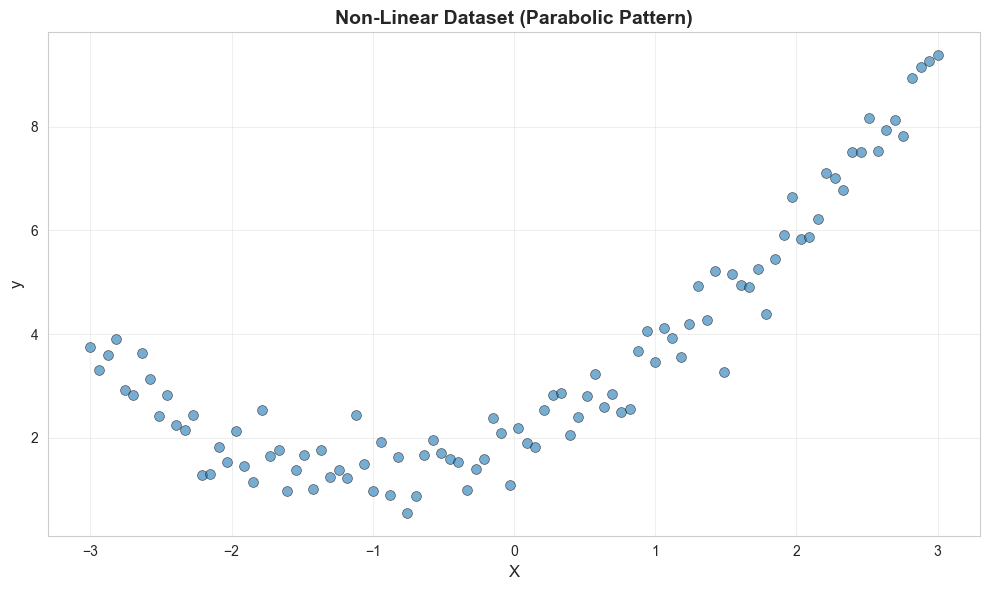

💡 Interpretasi:
Data menunjukkan pola parabola (kurva kuadrat).
Linear regression sederhana tidak akan cocok untuk data ini.
Kita perlu Polynomial Regression!


In [144]:
plt.figure(figsize=(10, 6))
plt.scatter(X_poly, y_poly, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Non-Linear Dataset (Parabolic Pattern)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Interpretasi:")
print("Data menunjukkan pola parabola (kurva kuadrat).")
print("Linear regression sederhana tidak akan cocok untuk data ini.")
print("Kita perlu Polynomial Regression!")

### 3.3 Split Data

In [145]:
# Split data
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y_poly, test_size=0.2, random_state=42
)

print(f"Training set: {X_train_poly.shape}")
print(f"Testing set: {X_test_poly.shape}")

Training set: (80, 1)
Testing set: (20, 1)


### 3.4 Compare Different Polynomial Degrees (1-10)

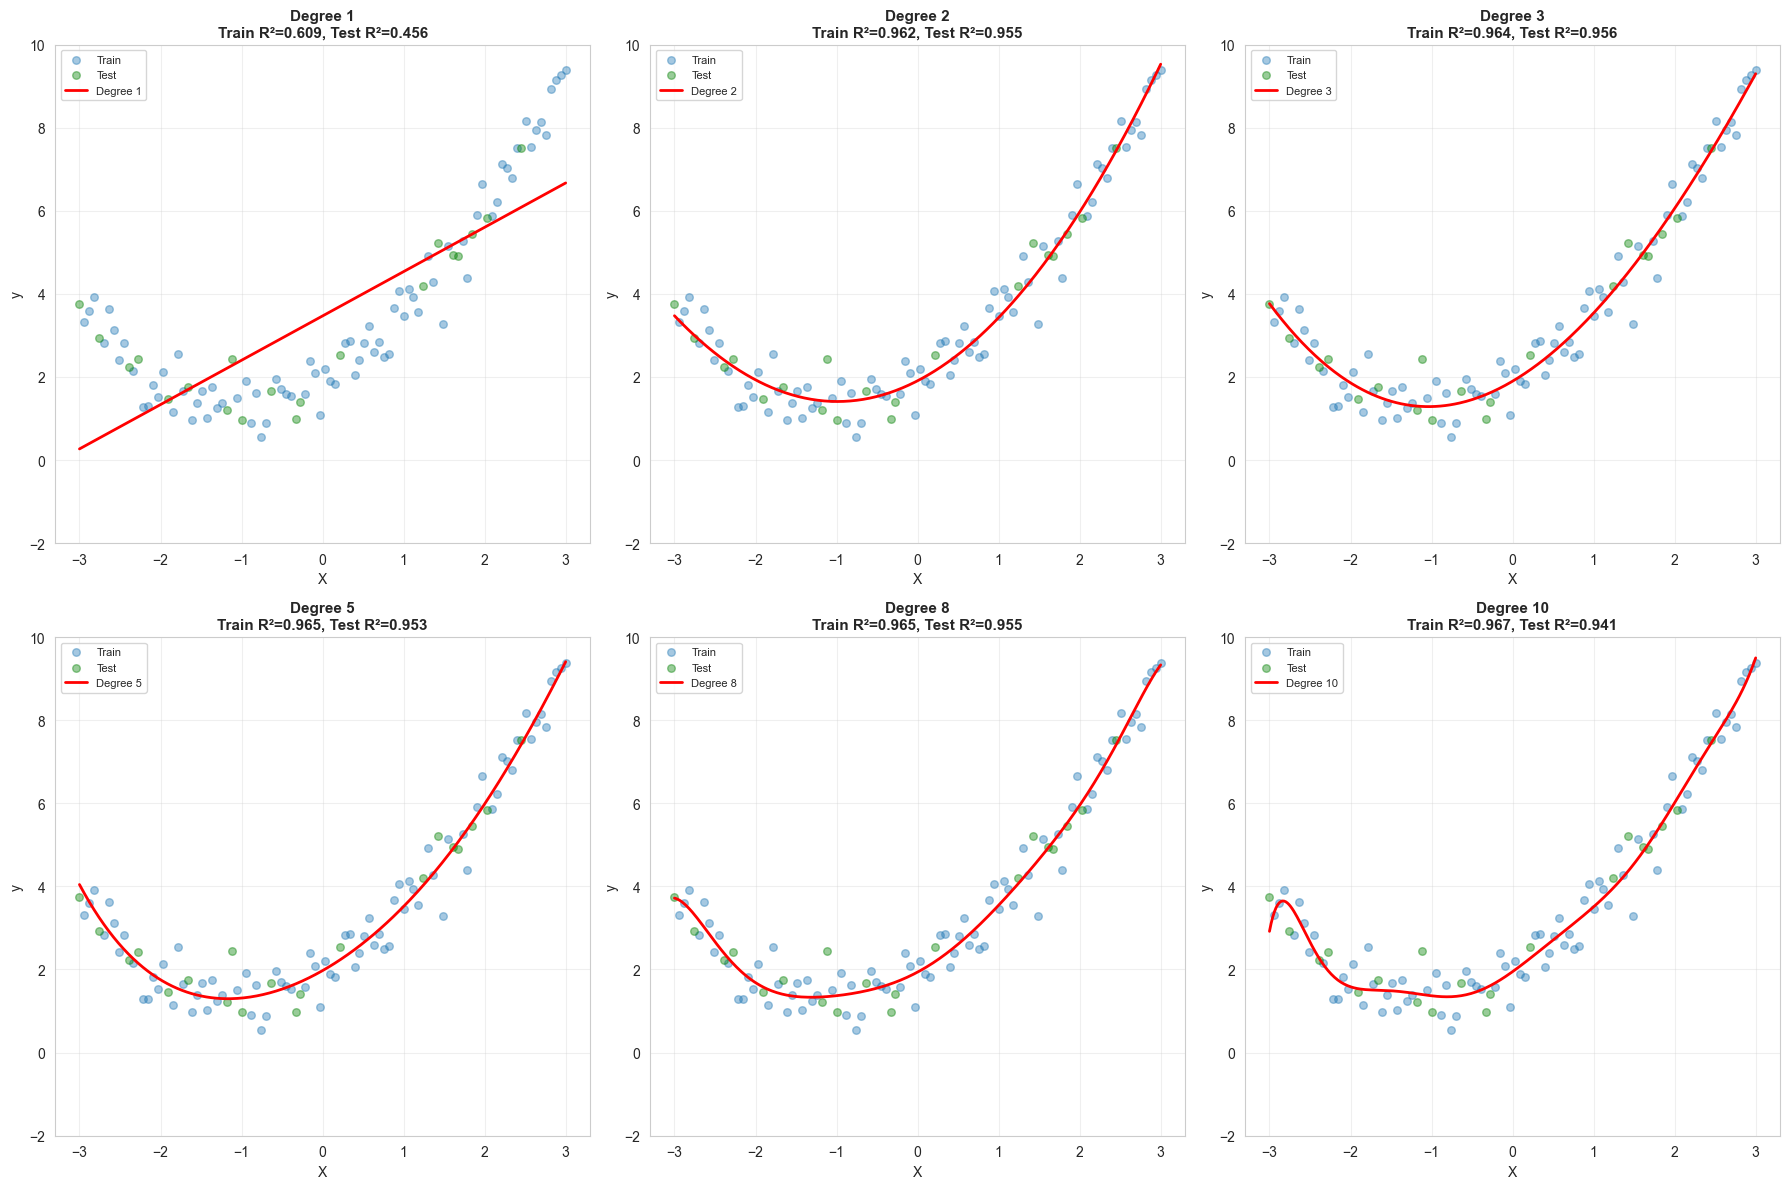


 HASIL POLYNOMIAL REGRESSION - BERBAGAI DEGREE
 Degree  Train R²  Test R²  Overfit
      1  0.609315 0.455970 0.153345
      2  0.962379 0.955124 0.007256
      3  0.964314 0.956383 0.007931
      5  0.965138 0.952988 0.012150
      8  0.965498 0.954955 0.010543
     10  0.967231 0.940809 0.026422


In [146]:
degrees = [1, 2, 3, 5, 8, 10]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

results = []

for idx, degree in enumerate(degrees):
    # Transform features
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly_transformed = poly_features.fit_transform(X_train_poly)
    X_test_poly_transformed = poly_features.transform(X_test_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_train_poly_transformed, y_train_poly)
    y_pred_train = model_poly.predict(X_train_poly_transformed)
    y_pred_test = model_poly.predict(X_test_poly_transformed)
    train_r2 = r2_score(y_train_poly, y_pred_train)
    test_r2 = r2_score(y_test_poly, y_pred_test)
    
    results.append({
        'Degree': degree,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Overfit': train_r2 - test_r2
    })
    
    # For plotting smooth curve
    X_range = np.linspace(-3, 3, 300).reshape(-1, 1)
    X_range_poly = poly_features.transform(X_range)
    y_range_pred = model_poly.predict(X_range_poly)
    
    # Plot
    axes[idx].scatter(X_train_poly, y_train_poly, alpha=0.4, s=30, label='Train')
    axes[idx].scatter(X_test_poly, y_test_poly, alpha=0.4, s=30, color='green', label='Test')
    axes[idx].plot(X_range, y_range_pred, color='red', linewidth=2, label=f'Degree {degree}')
    axes[idx].set_xlabel('X', fontsize=10)
    axes[idx].set_ylabel('y', fontsize=10)
    axes[idx].set_title(f'Degree {degree}\nTrain R²={train_r2:.3f}, Test R²={test_r2:.3f}', 
                       fontweight='bold', fontsize=11)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-2, 10)

plt.tight_layout()
plt.show()

# Print results table
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print(" HASIL POLYNOMIAL REGRESSION - BERBAGAI DEGREE")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

### 3.5 Learning Curve Analysis (Degree 1-15)

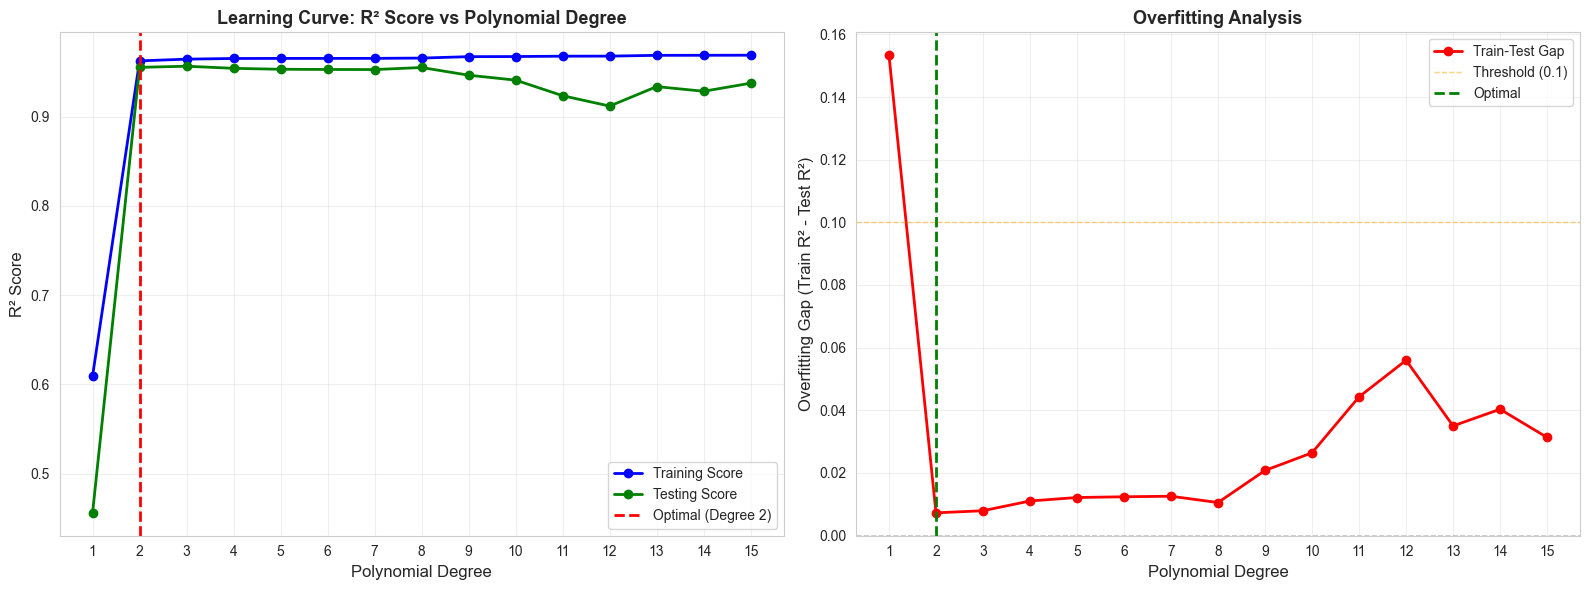

In [147]:
# Test degrees 1-15
degrees_full = range(1, 16)
train_scores = []
test_scores = []
overfitting_gap = []

for degree in degrees_full:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly_t = poly_features.fit_transform(X_train_poly)
    X_test_poly_t = poly_features.transform(X_test_poly)
    
    model = LinearRegression()
    model.fit(X_train_poly_t, y_train_poly)
    
    train_r2 = r2_score(y_train_poly, model.predict(X_train_poly_t))
    test_r2 = r2_score(y_test_poly, model.predict(X_test_poly_t))
    
    train_scores.append(train_r2)
    test_scores.append(test_r2)
    overfitting_gap.append(train_r2 - test_r2)

# Plot learning curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² Score Curve
axes[0].plot(degrees_full, train_scores, 'o-', label='Training Score', 
            linewidth=2, markersize=6, color='blue')
axes[0].plot(degrees_full, test_scores, 'o-', label='Testing Score', 
            linewidth=2, markersize=6, color='green')
axes[0].axvline(x=2, color='red', linestyle='--', linewidth=2, label='Optimal (Degree 2)')
axes[0].set_xlabel('Polynomial Degree', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Learning Curve: R² Score vs Polynomial Degree', 
                 fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(degrees_full)

# Overfitting Gap
axes[1].plot(degrees_full, overfitting_gap, 'o-', linewidth=2, 
            markersize=6, color='red', label='Train-Test Gap')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].axhline(y=0.1, color='orange', linestyle='--', linewidth=1, 
               alpha=0.5, label='Threshold (0.1)')
axes[1].axvline(x=2, color='green', linestyle='--', linewidth=2, label='Optimal')
axes[1].set_xlabel('Polynomial Degree', fontsize=12)
axes[1].set_ylabel('Overfitting Gap (Train R² - Test R²)', fontsize=12)
axes[1].set_title('Overfitting Analysis', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(degrees_full)

plt.tight_layout()
plt.show()

### 3.6 Identifikasi Degree Optimal

In [148]:
# Find optimal degree
optimal_idx = np.argmax(test_scores)
optimal_degree = list(degrees_full)[optimal_idx]
optimal_test_r2 = test_scores[optimal_idx]
optimal_train_r2 = train_scores[optimal_idx]

print("="*70)
print(" IDENTIFIKASI DEGREE OPTIMAL")
print("="*70)
print(f"\n DEGREE OPTIMAL: {optimal_degree}")
print(f"   - Train R² Score: {optimal_train_r2:.4f}")
print(f"   - Test R² Score: {optimal_test_r2:.4f}")
print(f"   - Overfitting Gap: {optimal_train_r2 - optimal_test_r2:.4f}")

print("\n" + "="*70)
print(" ANALISIS BERDASARKAN DEGREE")
print("="*70)

# Analysis for each degree range
for i, degree in enumerate(degrees_full):
    gap = overfitting_gap[i]
    test_r2 = test_scores[i]
    
    if degree == 1:
        status = " UNDERFITTING"
        reason = "Model terlalu sederhana, tidak bisa menangkap pola non-linear"
    elif degree <= 3:
        status = " GOOD FIT"
        reason = "Model dapat menangkap pola dengan baik tanpa overfitting"
    elif degree <= 6:
        status = " BORDERLINE"
        reason = "Mulai ada indikasi overfitting, gap train-test meningkat"
    else:
        status = " OVERFITTING"
        reason = "Model terlalu kompleks, menghafal noise, performa test menurun"
    
    print(f"\nDegree {degree:2d}: {status}")
    print(f"  Test R²: {test_r2:.4f} | Gap: {gap:.4f}")
    print(f"  Alasan: {reason}")

print("\n" + "="*70)

 IDENTIFIKASI DEGREE OPTIMAL

 DEGREE OPTIMAL: 3
   - Train R² Score: 0.9643
   - Test R² Score: 0.9564
   - Overfitting Gap: 0.0079

 ANALISIS BERDASARKAN DEGREE

Degree  1:  UNDERFITTING
  Test R²: 0.4560 | Gap: 0.1533
  Alasan: Model terlalu sederhana, tidak bisa menangkap pola non-linear

Degree  2:  GOOD FIT
  Test R²: 0.9551 | Gap: 0.0073
  Alasan: Model dapat menangkap pola dengan baik tanpa overfitting

Degree  3:  GOOD FIT
  Test R²: 0.9564 | Gap: 0.0079
  Alasan: Model dapat menangkap pola dengan baik tanpa overfitting

Degree  4:  BORDERLINE
  Test R²: 0.9540 | Gap: 0.0110
  Alasan: Mulai ada indikasi overfitting, gap train-test meningkat

Degree  5:  BORDERLINE
  Test R²: 0.9530 | Gap: 0.0122
  Alasan: Mulai ada indikasi overfitting, gap train-test meningkat

Degree  6:  BORDERLINE
  Test R²: 0.9528 | Gap: 0.0124
  Alasan: Mulai ada indikasi overfitting, gap train-test meningkat

Degree  7:  OVERFITTING
  Test R²: 0.9526 | Gap: 0.0126
  Alasan: Model terlalu kompleks, mengh

### 3.7 Penjelasan Underfitting vs Overfitting

In [149]:
print("="*80)
print(" PENJELASAN: UNDERFITTING vs GOOD FIT vs OVERFITTING")
print("="*80)

print("\n UNDERFITTING (Degree 1):")
print("-"*80)
print("KARAKTERISTIK:")
print("  • Train R² rendah AND Test R² rendah")
print("  • Gap kecil antara train dan test")
print("  • Model terlalu SEDERHANA")
print("\nPENYEBAB:")
print("  • Model linear tidak bisa menangkap hubungan non-linear")
print("  • Degree polynomial terlalu rendah")
print("  • Bias tinggi (high bias)")
print("\nSOLUSI:")
print("   Tingkatkan kompleksitas model (degree lebih tinggi)")
print("   Tambah fitur yang relevan")
print("   Gunakan model yang lebih kompleks")

print("\n\n GOOD FIT (Degree 2-3):")
print("-"*80)
print("KARAKTERISTIK:")
print("  • Train R² tinggi AND Test R² tinggi")
print("  • Gap kecil antara train dan test (<0.05)")
print("  • Model SEIMBANG")
print("\nKEUNGGULAN:")
print("  • Generalisasi baik ke data baru")
print("  • Tidak terlalu sederhana, tidak terlalu kompleks")
print("  • Balance antara bias dan variance")
print("\nINI ADALAH TARGET OPTIMAL!")

print("\n\n OVERFITTING (Degree 10+):")
print("-"*80)
print("KARAKTERISTIK:")
print("  • Train R² sangat tinggi (mendekati 1.0)")
print("  • Test R² menurun atau lebih rendah dari degree optimal")
print("  • Gap BESAR antara train dan test (>0.1)")
print("  • Model terlalu KOMPLEKS")
print("\nPENYEBAB:")
print("  • Model 'menghafal' noise di training data")
print("  • Degree polynomial terlalu tinggi")
print("  • Variance tinggi (high variance)")
print("  • Kurva terlalu 'bergelombang' mengikuti setiap titik")
print("\nSOLUSI:")
print("   Kurangi kompleksitas model (degree lebih rendah)")
print("   Gunakan regularization (Ridge/Lasso)")
print("   Tambah data training")
print("   Cross-validation untuk validasi")
print("   Early stopping")

print("\n\n SUMMARY TABLE:")
print("="*80)
summary = pd.DataFrame({
    'Kondisi': ['Underfitting', 'Good Fit', 'Overfitting'],
    'Train Score': ['Rendah', 'Tinggi', 'Sangat Tinggi'],
    'Test Score': ['Rendah', 'Tinggi', 'Rendah/Menurun'],
    'Train-Test Gap': ['Kecil', 'Kecil', 'BESAR'],
    'Kompleksitas': ['Terlalu Rendah', 'Optimal', 'Terlalu Tinggi'],
    'Masalah': ['High Bias', 'Balanced', 'High Variance']
})
print(summary.to_string(index=False))
print("="*80)

print("\n CARA MENDETEKSI:")
print("="*80)
print("1. UNDERFITTING → Train R² < 0.7 DAN Test R² < 0.7")
print("2. GOOD FIT → Train R² > 0.8 DAN Test R² > 0.8 DAN Gap < 0.05")
print("3. OVERFITTING → Train R² ≈ 1.0 DAN Test R² turun DAN Gap > 0.1")
print("="*80)

 PENJELASAN: UNDERFITTING vs GOOD FIT vs OVERFITTING

 UNDERFITTING (Degree 1):
--------------------------------------------------------------------------------
KARAKTERISTIK:
  • Train R² rendah AND Test R² rendah
  • Gap kecil antara train dan test
  • Model terlalu SEDERHANA

PENYEBAB:
  • Model linear tidak bisa menangkap hubungan non-linear
  • Degree polynomial terlalu rendah
  • Bias tinggi (high bias)

SOLUSI:
   Tingkatkan kompleksitas model (degree lebih tinggi)
   Tambah fitur yang relevan
   Gunakan model yang lebih kompleks


 GOOD FIT (Degree 2-3):
--------------------------------------------------------------------------------
KARAKTERISTIK:
  • Train R² tinggi AND Test R² tinggi
  • Gap kecil antara train dan test (<0.05)
  • Model SEIMBANG

KEUNGGULAN:
  • Generalisasi baik ke data baru
  • Tidak terlalu sederhana, tidak terlalu kompleks
  • Balance antara bias dan variance

INI ADALAH TARGET OPTIMAL!


 OVERFITTING (Degree 10+):
---------------------------------------

### 3.8 Evaluasi Model Optimal (Degree 2)

 EVALUASI MODEL OPTIMAL (Degree 3)

Train R² Score: 0.9643
Test R² Score: 0.9564

Train MAE: 0.3687
Test MAE: 0.2916

Train RMSE: 0.4517
Test RMSE: 0.3880


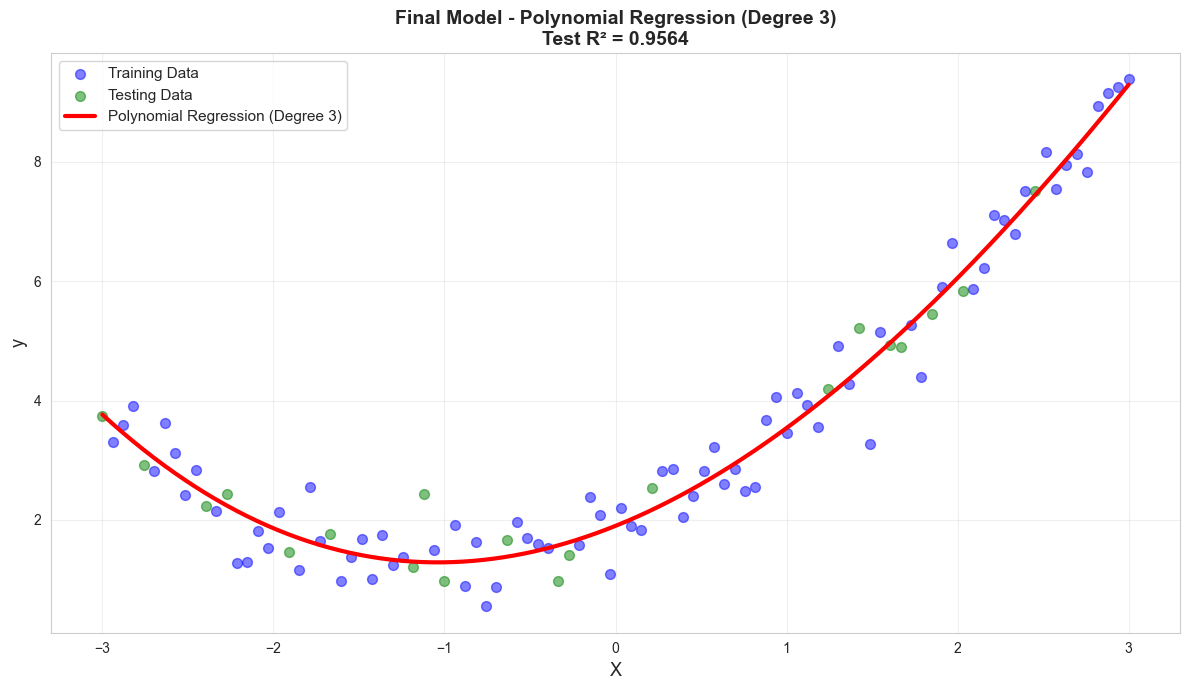

In [150]:
# Train final model dengan degree optimal
poly_features_optimal = PolynomialFeatures(degree=optimal_degree, include_bias=False)
X_train_optimal = poly_features_optimal.fit_transform(X_train_poly)
X_test_optimal = poly_features_optimal.transform(X_test_poly)

model_optimal = LinearRegression()
model_optimal.fit(X_train_optimal, y_train_poly)

y_pred_train_optimal = model_optimal.predict(X_train_optimal)
y_pred_test_optimal = model_optimal.predict(X_test_optimal)

# Evaluasi
print("="*70)
print(f" EVALUASI MODEL OPTIMAL (Degree {optimal_degree})")
print("="*70)
print(f"\nTrain R² Score: {r2_score(y_train_poly, y_pred_train_optimal):.4f}")
print(f"Test R² Score: {r2_score(y_test_poly, y_pred_test_optimal):.4f}")
print(f"\nTrain MAE: {mean_absolute_error(y_train_poly, y_pred_train_optimal):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test_poly, y_pred_test_optimal):.4f}")
print(f"\nTrain RMSE: {np.sqrt(mean_squared_error(y_train_poly, y_pred_train_optimal)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_poly, y_pred_test_optimal)):.4f}")
print("="*70)

# Visualisasi final model
X_range = np.linspace(-3, 3, 300).reshape(-1, 1)
X_range_poly = poly_features_optimal.transform(X_range)
y_range_pred = model_optimal.predict(X_range_poly)

plt.figure(figsize=(12, 7))
plt.scatter(X_train_poly, y_train_poly, alpha=0.5, s=50, label='Training Data', color='blue')
plt.scatter(X_test_poly, y_test_poly, alpha=0.5, s=50, label='Testing Data', color='green')
plt.plot(X_range, y_range_pred, color='red', linewidth=3, 
         label=f'Polynomial Regression (Degree {optimal_degree})')
plt.xlabel('X', fontsize=13)
plt.ylabel('y', fontsize=13)
plt.title(f'Final Model - Polynomial Regression (Degree {optimal_degree})\nTest R² = {optimal_test_r2:.4f}', 
         fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
<a id='tugas4'></a>
## 5. Tugas 4: Real-World Application - Prediksi Gaji (20 poin)

### Objektif:
Prediksi gaji berdasarkan years of experience menggunakan dataset real-world.

**Task:**
1. Collect/download dataset
2. EDA singkat
3. Preprocessing (handling missing values, scaling)
4. Train model (linear atau polynomial)
5. Evaluasi dan interpretasi
6. Kesimpulan

### 4.1 Generate Salary Dataset

In [ ]:
# Generate realistic salary dataset
np.random.seed(42)

# Years of experience (0-20 years)
experience = np.random.uniform(0, 20, 200)

salary = (
    30000 + 
    3000 * experience + 
    100 * (experience ** 1.5) + 
    np.random.normal(0, 5000, 200)
)

# Create DataFrame
df_salary = pd.DataFrame({
    'Years_Experience': experience,
    'Salary': salary
})

# Sort by experience
df_salary = df_salary.sort_values('Years_Experience').reset_index(drop=True)

print("="*70)
print(" SALARY PREDICTION DATASET")
print("="*70)
print(f"\nDataset Shape: {df_salary.shape}")
print(f"\nFirst 10 rows:")
print(df_salary.head(10))
print(f"\nStatistical Summary:")
print(df_salary.describe())

 SALARY PREDICTION DATASET

Dataset Shape: (200, 2)

First 10 rows:
   Years_Experience        Salary
0          0.110442  27975.338014
1          0.139043  30989.899237
2          0.331757  41476.314734
3          0.411690  37054.462838
4          0.508383  25256.975990
5          0.628584  42546.368299
6          0.687770  32986.254021
7          0.737739  33813.080121
8          0.815503  33005.132461
9          0.904546  35654.119077

Statistical Summary:
       Years_Experience         Salary
count        200.000000     200.000000
mean           9.680125   62823.854105
std            5.897829   20863.616620
min            0.110442   25256.975990
25%            4.571648   44294.335846
50%            9.889725   61116.178406
75%           15.137192   80752.980955
max           19.737739  104279.796577


### 4.2 Exploratory Data Analysis (EDA)

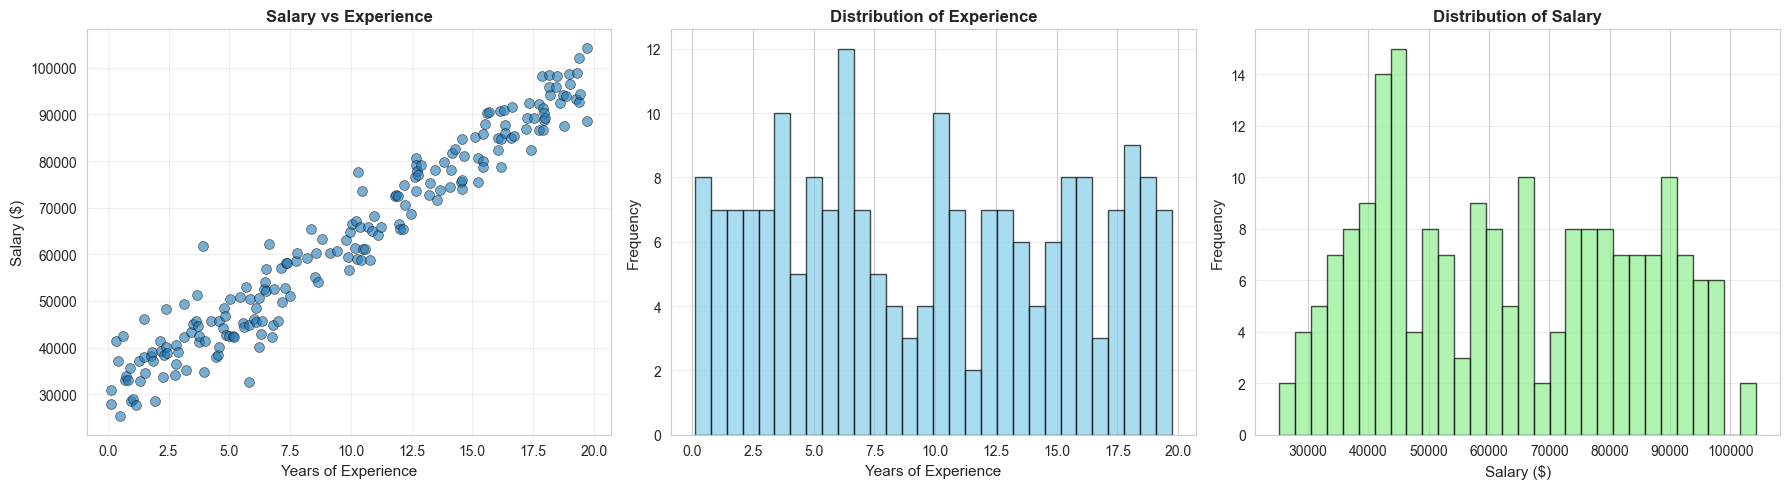


 EDA Insights:
1. Range Experience: 0.1 - 19.7 years
2. Range Salary: $25,257 - $104,280
3. Mean Salary: $62,824
4. Median Salary: $61,116
5. Correlation: 0.9722

 Strong positive correlation - experience meningkat, salary meningkat!


In [161]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot
axes[0].scatter(df_salary['Years_Experience'], df_salary['Salary'], 
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Years of Experience', fontsize=11)
axes[0].set_ylabel('Salary ($)', fontsize=11)
axes[0].set_title('Salary vs Experience', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Distribution of Experience
axes[1].hist(df_salary['Years_Experience'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[1].set_xlabel('Years of Experience', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Experience', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Distribution of Salary
axes[2].hist(df_salary['Salary'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].set_xlabel('Salary ($)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Distribution of Salary', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n EDA Insights:")
print("="*70)
print(f"1. Range Experience: {df_salary['Years_Experience'].min():.1f} - {df_salary['Years_Experience'].max():.1f} years")
print(f"2. Range Salary: ${df_salary['Salary'].min():,.0f} - ${df_salary['Salary'].max():,.0f}")
print(f"3. Mean Salary: ${df_salary['Salary'].mean():,.0f}")
print(f"4. Median Salary: ${df_salary['Salary'].median():,.0f}")
print(f"5. Correlation: {df_salary['Years_Experience'].corr(df_salary['Salary']):.4f}")
print("\n Strong positive correlation - experience meningkat, salary meningkat!")

### 4.3 Data Preprocessing

In [162]:
# Check missing values
print(" Checking Missing Values:")
print(df_salary.isnull().sum())
print("\n No missing values!")

# Check outliers using IQR method
Q1 = df_salary['Salary'].quantile(0.25)
Q3 = df_salary['Salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_salary[(df_salary['Salary'] < lower_bound) | (df_salary['Salary'] > upper_bound)]
print(f"\n Outlier Detection (IQR Method):")
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage: {len(outliers)/len(df_salary)*100:.2f}%")

if len(outliers) > 0:
    print(f"\nOutliers:")
    print(outliers)
else:
    print(" No significant outliers detected!")

# Prepare features
X_salary = df_salary[['Years_Experience']].values
y_salary = df_salary['Salary'].values

print(f"\n Data prepared:")
print(f"X shape: {X_salary.shape}")
print(f"y shape: {y_salary.shape}")

 Checking Missing Values:
Years_Experience    0
Salary              0
dtype: int64

 No missing values!

 Outlier Detection (IQR Method):
Number of outliers: 0
Percentage: 0.00%
 No significant outliers detected!

 Data prepared:
X shape: (200, 1)
y shape: (200,)


### 4.4 Split Data & Train Models

In [154]:
# Split data
X_train_sal, X_test_sal, y_train_sal, y_test_sal = train_test_split(
    X_salary, y_salary, test_size=0.2, random_state=42
)

print(f"Training set: {X_train_sal.shape}")
print(f"Testing set: {X_test_sal.shape}")

# Model 1: Linear Regression
model_linear_sal = LinearRegression()
model_linear_sal.fit(X_train_sal, y_train_sal)

y_pred_train_linear = model_linear_sal.predict(X_train_sal)
y_pred_test_linear = model_linear_sal.predict(X_test_sal)

# Model 2: Polynomial Regression (Degree 2)
poly_sal = PolynomialFeatures(degree=2, include_bias=False)
X_train_sal_poly = poly_sal.fit_transform(X_train_sal)
X_test_sal_poly = poly_sal.transform(X_test_sal)

model_poly_sal = LinearRegression()
model_poly_sal.fit(X_train_sal_poly, y_train_sal)

y_pred_train_poly = model_poly_sal.predict(X_train_sal_poly)
y_pred_test_poly = model_poly_sal.predict(X_test_sal_poly)

print("\n Both models trained successfully!")

Training set: (160, 1)
Testing set: (40, 1)

 Both models trained successfully!


### 4.5 Model Evaluation & Comparison

 MODEL COMPARISON - SALARY PREDICTION
             Model Dataset  R² Score     MAE ($)    RMSE ($)
            Linear   Train  0.944495 3997.221848 5014.410108
            Linear    Test  0.948087 3274.452883 4282.269959
Polynomial (Deg 2)   Train  0.945204 3964.364395 4982.283624
Polynomial (Deg 2)    Test  0.951140 3219.775081 4154.438759


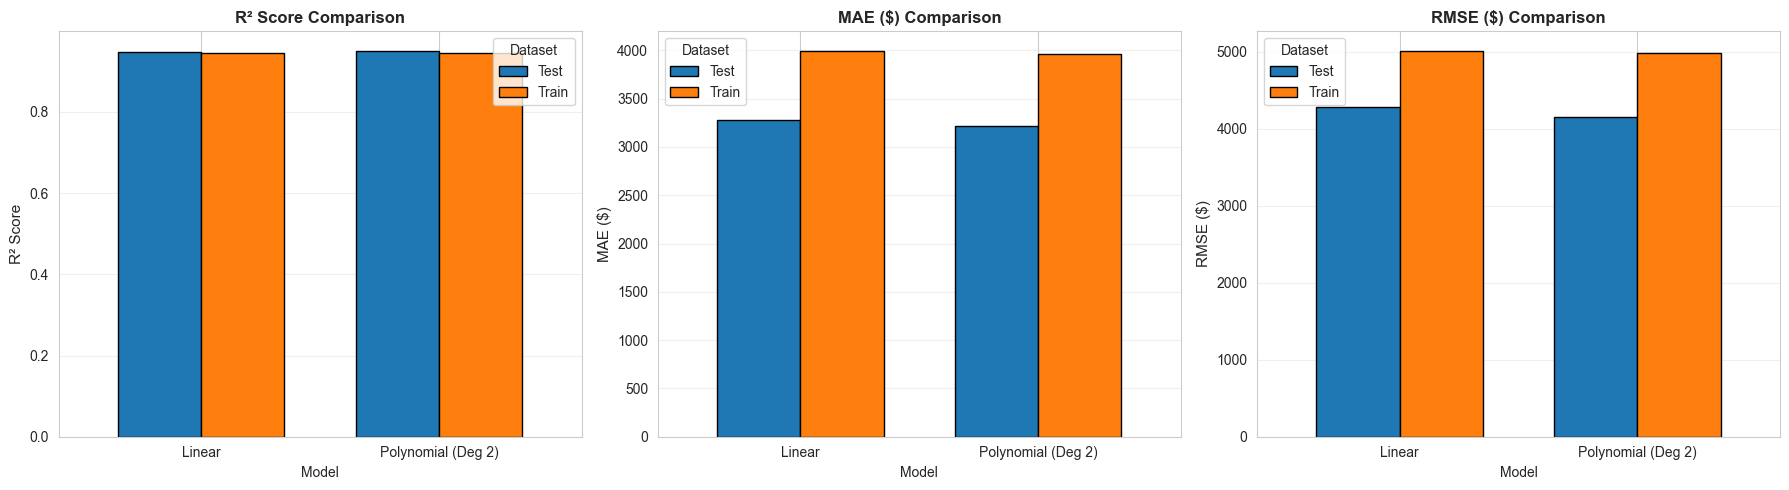

In [155]:
# Evaluate Linear Model
linear_train_r2 = r2_score(y_train_sal, y_pred_train_linear)
linear_test_r2 = r2_score(y_test_sal, y_pred_test_linear)
linear_train_mae = mean_absolute_error(y_train_sal, y_pred_train_linear)
linear_test_mae = mean_absolute_error(y_test_sal, y_pred_test_linear)
linear_train_rmse = np.sqrt(mean_squared_error(y_train_sal, y_pred_train_linear))
linear_test_rmse = np.sqrt(mean_squared_error(y_test_sal, y_pred_test_linear))

# Evaluate Polynomial Model
poly_train_r2 = r2_score(y_train_sal, y_pred_train_poly)
poly_test_r2 = r2_score(y_test_sal, y_pred_test_poly)
poly_train_mae = mean_absolute_error(y_train_sal, y_pred_train_poly)
poly_test_mae = mean_absolute_error(y_test_sal, y_pred_test_poly)
poly_train_rmse = np.sqrt(mean_squared_error(y_train_sal, y_pred_train_poly))
poly_test_rmse = np.sqrt(mean_squared_error(y_test_sal, y_pred_test_poly))

# Comparison table
comparison_sal = pd.DataFrame({
    'Model': ['Linear', 'Linear', 'Polynomial (Deg 2)', 'Polynomial (Deg 2)'],
    'Dataset': ['Train', 'Test', 'Train', 'Test'],
    'R² Score': [linear_train_r2, linear_test_r2, poly_train_r2, poly_test_r2],
    'MAE ($)': [linear_train_mae, linear_test_mae, poly_train_mae, poly_test_mae],
    'RMSE ($)': [linear_train_rmse, linear_test_rmse, poly_train_rmse, poly_test_rmse]
})

print("="*90)
print(" MODEL COMPARISON - SALARY PREDICTION")
print("="*90)
print(comparison_sal.to_string(index=False))
print("="*90)

# Visualisasi comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_sal = ['R² Score', 'MAE ($)', 'RMSE ($)']
for idx, metric in enumerate(metrics_sal):
    data_plot = comparison_sal.pivot(index='Model', columns='Dataset', values=metric)
    data_plot.plot(kind='bar', ax=axes[idx], edgecolor='black', width=0.7, rot=0)
    axes[idx].set_title(f'{metric} Comparison', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel(metric, fontsize=11)
    axes[idx].legend(title='Dataset')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 4.6 Visualisasi Model Predictions

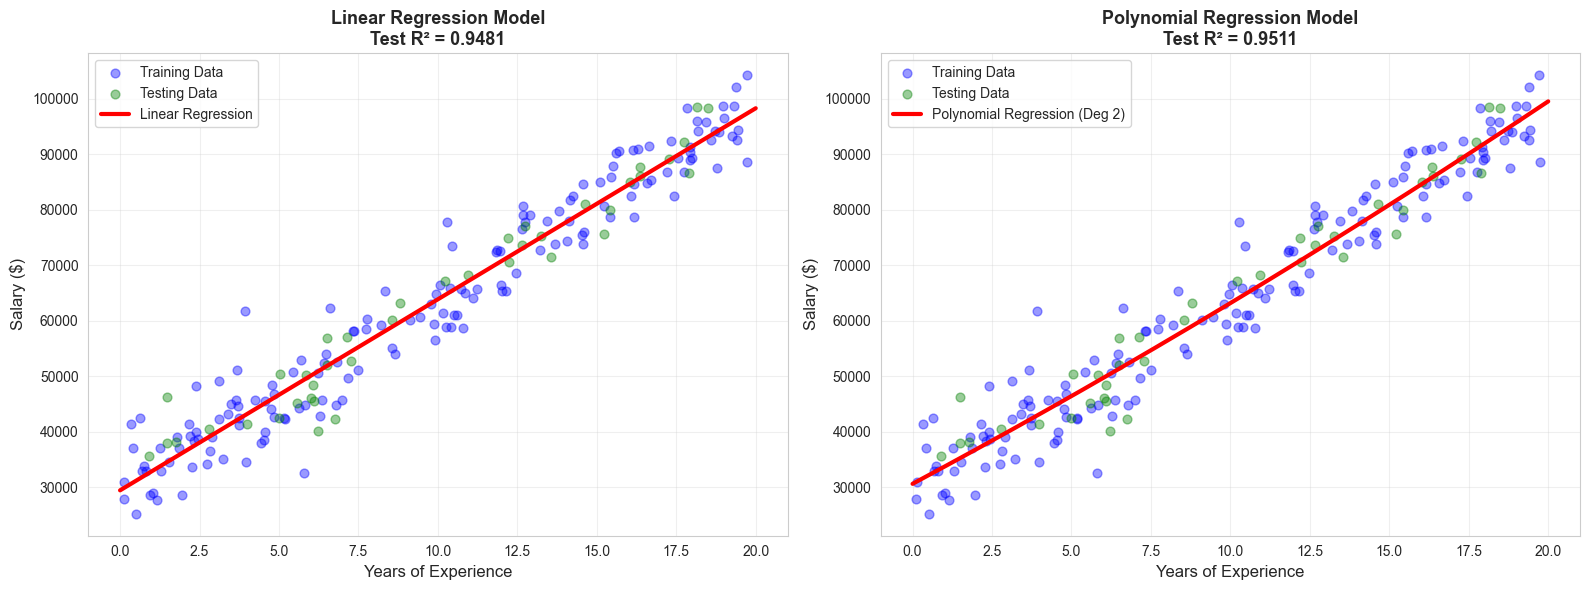

In [156]:
# Create smooth line for visualization
X_range_sal = np.linspace(0, 20, 300).reshape(-1, 1)
y_pred_linear_range = model_linear_sal.predict(X_range_sal)
y_pred_poly_range = model_poly_sal.predict(poly_sal.transform(X_range_sal))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Model
axes[0].scatter(X_train_sal, y_train_sal, alpha=0.4, s=40, label='Training Data', color='blue')
axes[0].scatter(X_test_sal, y_test_sal, alpha=0.4, s=40, label='Testing Data', color='green')
axes[0].plot(X_range_sal, y_pred_linear_range, color='red', linewidth=3, label='Linear Regression')
axes[0].set_xlabel('Years of Experience', fontsize=12)
axes[0].set_ylabel('Salary ($)', fontsize=12)
axes[0].set_title(f'Linear Regression Model\nTest R² = {linear_test_r2:.4f}', 
                 fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Polynomial Model
axes[1].scatter(X_train_sal, y_train_sal, alpha=0.4, s=40, label='Training Data', color='blue')
axes[1].scatter(X_test_sal, y_test_sal, alpha=0.4, s=40, label='Testing Data', color='green')
axes[1].plot(X_range_sal, y_pred_poly_range, color='red', linewidth=3, 
            label='Polynomial Regression (Deg 2)')
axes[1].set_xlabel('Years of Experience', fontsize=12)
axes[1].set_ylabel('Salary ($)', fontsize=12)
axes[1].set_title(f'Polynomial Regression Model\nTest R² = {poly_test_r2:.4f}', 
                 fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.7 Interpretasi Model

In [163]:
print("="*80)
print(" INTERPRETASI MODEL SALARY PREDICTION")
print("="*80)

print("\n MODEL LINEAR REGRESSION:")
print("-"*80)
print(f"Intercept (β₀): ${model_linear_sal.intercept_:,.2f}")
print(f"Coefficient (β₁): ${model_linear_sal.coef_[0]:,.2f}")
print(f"\nPersamaan: Salary = ${model_linear_sal.intercept_:,.0f} + ${model_linear_sal.coef_[0]:,.0f} × Experience")
print(f"\nInterpretasi:")
print(f"  • Gaji awal (0 tahun pengalaman): ${model_linear_sal.intercept_:,.0f}")
print(f"  • Setiap tambahan 1 tahun pengalaman → Gaji naik ${model_linear_sal.coef_[0]:,.0f}")
print(f"  • Model Performance: R² = {linear_test_r2:.4f}, MAE = ${linear_test_mae:,.0f}")

print("\n MODEL POLYNOMIAL REGRESSION (Degree 2):")
print("-"*80)
print(f"Intercept: ${model_poly_sal.intercept_:,.2f}")
print(f"Coefficients: {model_poly_sal.coef_}")
print(f"\nInterpretasi:")
print(f"  • Model dapat menangkap hubungan NON-LINEAR antara experience dan salary")
print(f"  • Kenaikan salary tidak konstan, tetapi accelerating dengan bertambahnya pengalaman")
print(f"  • Model Performance: R² = {poly_test_r2:.4f}, MAE = ${poly_test_mae:,.0f}")

print("\n PERBANDINGAN:")
print("-"*80)
if poly_test_r2 > linear_test_r2:
    improvement = (poly_test_r2 - linear_test_r2) / linear_test_r2 * 100
    print(f" Polynomial model LEBIH BAIK!")
    print(f"   Improvement R²: {improvement:.2f}%")
    print(f"   Reduction MAE: ${linear_test_mae - poly_test_mae:,.0f}")
    best_model = "Polynomial"
else:
    print(f" Linear model sudah CUKUP BAIK!")
    print(f"   Hubungan relatif linear")
    best_model = "Linear"

print(f"\n REKOMENDASI:")
print("-"*80)
print(f"Model terbaik untuk prediksi: {best_model} Regression")
print(f"Akurasi prediksi: ±${poly_test_mae if best_model == 'Polynomial' else linear_test_mae:,.0f}")

 INTERPRETASI MODEL SALARY PREDICTION

 MODEL LINEAR REGRESSION:
--------------------------------------------------------------------------------
Intercept (β₀): $29,478.64
Coefficient (β₁): $3,441.24

Persamaan: Salary = $29,479 + $3,441 × Experience

Interpretasi:
  • Gaji awal (0 tahun pengalaman): $29,479
  • Setiap tambahan 1 tahun pengalaman → Gaji naik $3,441
  • Model Performance: R² = 0.9481, MAE = $3,274

 MODEL POLYNOMIAL REGRESSION (Degree 2):
--------------------------------------------------------------------------------
Intercept: $30,654.53
Coefficients: [3065.79376052   18.93318179]

Interpretasi:
  • Model dapat menangkap hubungan NON-LINEAR antara experience dan salary
  • Kenaikan salary tidak konstan, tetapi accelerating dengan bertambahnya pengalaman
  • Model Performance: R² = 0.9511, MAE = $3,220

 PERBANDINGAN:
--------------------------------------------------------------------------------
 Polynomial model LEBIH BAIK!
   Improvement R²: 0.32%
   Reduction MAE

### 4.8 Prediksi Salary untuk Berbagai Level Experience

🔮 PREDIKSI SALARY UNTUK BERBAGAI LEVEL EXPERIENCE
 Years Experience  Linear Prediction ($)  Polynomial Prediction ($)  Difference ($)
                1                $32,920                    $33,739            $819
                3                $39,802                    $40,022            $220
                5                $46,685                    $46,457           $-228
               10                $63,891                    $63,206           $-685
               15                $81,097                    $80,901           $-196
               20                $98,303                    $99,544          $1,240


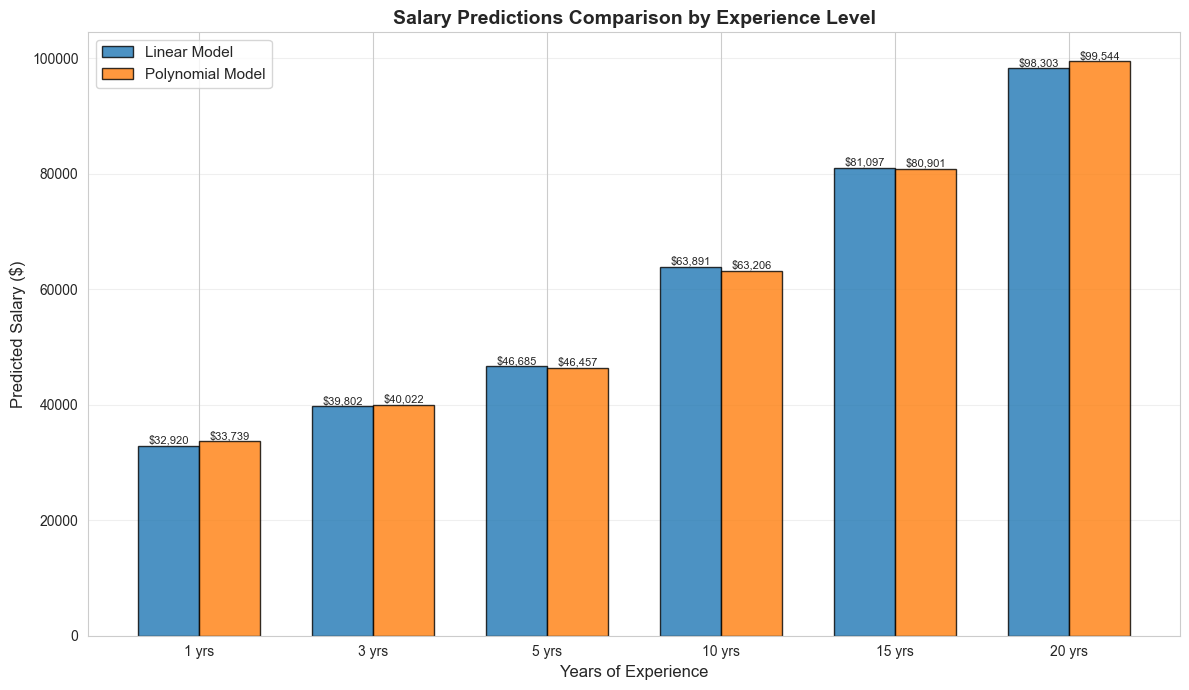

In [158]:
# Prediksi untuk berbagai tahun pengalaman
experience_levels = np.array([[1], [3], [5], [10], [15], [20]])

# Linear predictions
salary_pred_linear = model_linear_sal.predict(experience_levels)

# Polynomial predictions
salary_pred_poly = model_poly_sal.predict(poly_sal.transform(experience_levels))

# Create prediction table
predictions = pd.DataFrame({
    'Years Experience': experience_levels.squeeze(),
    'Linear Prediction ($)': salary_pred_linear,
    'Polynomial Prediction ($)': salary_pred_poly,
    'Difference ($)': salary_pred_poly - salary_pred_linear
})

print("="*90)
print("🔮 PREDIKSI SALARY UNTUK BERBAGAI LEVEL EXPERIENCE")
print("="*90)
print(predictions.to_string(index=False, float_format=lambda x: f'${x:,.0f}'))
print("="*90)

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(experience_levels))
width = 0.35

bars1 = ax.bar(x_pos - width/2, salary_pred_linear, width, 
              label='Linear Model', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, salary_pred_poly, width, 
              label='Polynomial Model', alpha=0.8, edgecolor='black')

ax.set_xlabel('Years of Experience', fontsize=12)
ax.set_ylabel('Predicted Salary ($)', fontsize=12)
ax.set_title('Salary Predictions Comparison by Experience Level', 
            fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{int(y)} yrs' for y in experience_levels.squeeze()])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'${height:,.0f}',
               ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 4.9 Kesimpulan Real-World Application

In [164]:
print("="*80)
print(" KESIMPULAN - SALARY PREDICTION PROJECT")
print("="*80)

print("\n1️ PERFORMA MODEL:")
print("-"*80)
print(f"   Linear Regression:")
print(f"     • R² Score: {linear_test_r2:.4f} ({linear_test_r2*100:.1f}% variance explained)")
print(f"     • MAE: ${linear_test_mae:,.0f} (rata-rata error)")
print(f"     • RMSE: ${linear_test_rmse:,.0f}")

print(f"\n   Polynomial Regression (Degree 2):")
print(f"     • R² Score: {poly_test_r2:.4f} ({poly_test_r2*100:.1f}% variance explained)")
print(f"     • MAE: ${poly_test_mae:,.0f} (rata-rata error)")
print(f"     • RMSE: ${poly_test_rmse:,.0f}")

print("\n2️ APAKAH MODEL CUKUP BAIK?")
print("-"*80)
if poly_test_r2 > 0.85:
    print("    YA! Model sangat baik (R² > 0.85)")
    print("      - Model dapat menjelaskan >85% variasi salary")
    print("      - Prediksi cukup akurat untuk decision making")
elif poly_test_r2 > 0.7:
    print("    YA! Model baik (R² > 0.7)")
    print("      - Model dapat menjelaskan >70% variasi salary")
    print("      - Dapat digunakan sebagai reference")
else:
    print("    Model perlu improvement (R² < 0.7)")
    print("      - Masih ada variasi yang belum tertangkap")

print(f"\n   Error Rate: ±${poly_test_mae:,.0f} ({poly_test_mae/df_salary['Salary'].mean()*100:.1f}% dari rata-rata)")

print("\n3️ APA YANG BISA DITINGKATKAN?")
print("-"*80)
print("    POSSIBLE IMPROVEMENTS:")
print("      1. Tambah fitur lain yang relevan:")
print("         - Education level (S1, S2, S3)")
print("         - Job position/role")
print("         - Company size")
print("         - Industry/sector")
print("         - Location/city")
print("         - Skills/certifications")
print("\n      2. Collect more data:")
print("         - Current dataset: 200 samples")
print("         - Target: 1000+ samples for better generalization")
print("\n      3. Try advanced models:")
print("         - Random Forest Regression")
print("         - Gradient Boosting")
print("         - Neural Networks")
print("\n      4. Feature engineering:")
print("         - Experience squared, cubed")
print("         - Interaction terms")
print("         - Categorical encoding for job roles")
print("\n      5. Regularization:")
print("         - Ridge Regression (L2)")
print("         - Lasso Regression (L1)")

print("\n BUSINESS INSIGHTS:")
print("-"*80)
print("    Implikasi untuk HR/Business:")
print(f"      • Fresh graduate (0 tahun): ~${model_poly_sal.predict(poly_sal.transform([[0]]))[0]:,.0f}")
print(f"      • Junior (3 tahun): ~${model_poly_sal.predict(poly_sal.transform([[3]]))[0]:,.0f}")
print(f"      • Mid-level (5 tahun): ~${model_poly_sal.predict(poly_sal.transform([[5]]))[0]:,.0f}")
print(f"      • Senior (10 tahun): ~${model_poly_sal.predict(poly_sal.transform([[10]]))[0]:,.0f}")
print(f"      • Expert (15+ tahun): ~${model_poly_sal.predict(poly_sal.transform([[15]]))[0]:,.0f}")

print("\n   Rekomendasi:")
print("      • Model dapat digunakan sebagai benchmark salary")
print("      • Perlu consider faktor lain (skill, performance, market)")
print("      • Update model secara berkala dengan data terbaru")

print("\n" + "="*80)
print(" PROJECT COMPLETED SUCCESSFULLY!")
print("="*80)

 KESIMPULAN - SALARY PREDICTION PROJECT

1️ PERFORMA MODEL:
--------------------------------------------------------------------------------
   Linear Regression:
     • R² Score: 0.9481 (94.8% variance explained)
     • MAE: $3,274 (rata-rata error)
     • RMSE: $4,282

   Polynomial Regression (Degree 2):
     • R² Score: 0.9511 (95.1% variance explained)
     • MAE: $3,220 (rata-rata error)
     • RMSE: $4,154

2️ APAKAH MODEL CUKUP BAIK?
--------------------------------------------------------------------------------
    YA! Model sangat baik (R² > 0.85)
      - Model dapat menjelaskan >85% variasi salary
      - Prediksi cukup akurat untuk decision making

   Error Rate: ±$3,220 (5.1% dari rata-rata)

3️ APA YANG BISA DITINGKATKAN?
--------------------------------------------------------------------------------
    POSSIBLE IMPROVEMENTS:
      1. Tambah fitur lain yang relevan:
         - Education level (S1, S2, S3)
         - Job position/role
         - Company size
         - 

---
<a id='kesimpulan'></a>
## 6. Kesimpulan Keseluruhan

### 🎯 Rangkuman Pembelajaran

In [165]:
print("="*90)
print(" KESIMPULAN PRAKTIKUM PERTEMUAN 3: LINEAR & POLYNOMIAL REGRESSION")
print("="*90)

print("\n YANG TELAH DIPELAJARI:")
print("-"*90)
print("\n1. SIMPLE LINEAR REGRESSION")
print("    Memahami konsep regresi linear dengan 1 fitur")
print("    Implementasi menggunakan scikit-learn")
print("    Interpretasi koefisien (intercept & slope)")
print("    Evaluasi menggunakan R², MAE, RMSE")
print("    Visualisasi regression line")

print("\n2. MULTIPLE LINEAR REGRESSION")
print("    Regresi dengan multiple features (California Housing)")
print("    Feature selection berdasarkan correlation")
print("    Perbandingan model all features vs top features")
print("    Residual analysis")
print("    Interpretasi koefisien untuk business insights")

print("\n3. POLYNOMIAL REGRESSION")
print("    Menangani hubungan non-linear")
print("    Testing berbagai polynomial degrees (1-15)")
print("    Learning curve analysis")
print("    Identifikasi optimal degree")
print("    Memahami underfitting vs overfitting")

print("\n4. REAL-WORLD APPLICATION")
print("    End-to-end ML project (Salary Prediction)")
print("    EDA dan preprocessing")
print("    Model comparison (Linear vs Polynomial)")
print("    Business interpretation")
print("    Recommendations untuk improvement")

print("\n KEY TAKEAWAYS:")
print("-"*90)
print("\n METRICS:")
print("   • R² Score: Proporsi variance yang dijelaskan (0-1, higher is better)")
print("   • MAE: Mean Absolute Error (rata-rata error absolut)")
print("   • RMSE: Root Mean Square Error (memberi penalty lebih pada error besar)")

print("\n BIAS-VARIANCE TRADEOFF:")
print("   • Underfitting: Model terlalu simple → High Bias")
print("   • Good Fit: Balance antara bias dan variance")
print("   • Overfitting: Model terlalu complex → High Variance")

print("\n MODEL SELECTION:")
print("   • Linear Regression: Untuk hubungan linear")
print("   • Polynomial Regression: Untuk hubungan non-linear")
print("   • Pilih degree optimal berdasarkan validation performance")

print("\n BEST PRACTICES:")
print("-"*90)
print("   1. Selalu lakukan EDA sebelum modeling")
print("   2. Check dan handle missing values & outliers")
print("   3. Split data (80-20 atau 70-30)")
print("   4. Train multiple models dan compare")
print("   5. Evaluasi dengan multiple metrics")
print("   6. Analyze residuals untuk validasi")
print("   7. Interpret results untuk business insights")
print("   8. Consider improvement opportunities")

print("\n NEXT STEPS:")
print("-"*90)
print("   • Pelajari Classification algorithms (Pertemuan 4)")
print("   • Explore Regularization (Ridge, Lasso)")
print("   • Try Cross-Validation")
print("   • Experiment dengan real datasets dari Kaggle")

print("\n" + "="*90)
print(" SELAMAT! ANDA TELAH MENYELESAIKAN PRAKTIKUM PERTEMUAN 3!")
print("="*90)
print("\n Keep learning and practicing! Machine Learning is a journey!")
print("\n Jangan lupa export notebook ini ke PDF dan submit ke LMS!")
print("\n" + "="*90)

 KESIMPULAN PRAKTIKUM PERTEMUAN 3: LINEAR & POLYNOMIAL REGRESSION

 YANG TELAH DIPELAJARI:
------------------------------------------------------------------------------------------

1. SIMPLE LINEAR REGRESSION
    Memahami konsep regresi linear dengan 1 fitur
    Implementasi menggunakan scikit-learn
    Interpretasi koefisien (intercept & slope)
    Evaluasi menggunakan R², MAE, RMSE
    Visualisasi regression line

2. MULTIPLE LINEAR REGRESSION
    Regresi dengan multiple features (California Housing)
    Feature selection berdasarkan correlation
    Perbandingan model all features vs top features
    Residual analysis
    Interpretasi koefisien untuk business insights

3. POLYNOMIAL REGRESSION
    Menangani hubungan non-linear
    Testing berbagai polynomial degrees (1-15)
    Learning curve analysis
    Identifikasi optimal degree
    Memahami underfitting vs overfitting

4. REAL-WORLD APPLICATION
    End-to-end ML project (Salary Prediction)
    EDA dan preprocessing
    Model co

---

## 📝 Catatan Akhir

**Dibuat oleh:** [Nur Adnan Yusri]

**NIM:** [105841115623]

**Mata Kuliah:** Applied Machine Learning

**Pertemuan:** 3 - Linear & Polynomial Regression

---

### 🎯 Checklist Sebelum Submit:

- [ ] Semua cell sudah di-run dan menampilkan output
- [ ] Tidak ada error di semua cell
- [ ] Interpretasi hasil sudah lengkap
- [ ] Visualisasi jelas dan informatif
- [ ] Code rapi dan ter-comment dengan baik
- [ ] Export ke PDF dengan nama: `NIM_Nama_Pertemuan03.pdf`

---

**Happy Learning! 🚀📊**